# Twinned FCC 3D Pipeline: Advanced Walkthrough (Optimization)

An end-to-end demonstration of the Twinned FCC pipeline built from modular
step functions (`steps/`), each independently inspectable and reusable
outside this notebook. This tier comprises the complete content of
`twinned_fcc_adv0.ipynb`, with two additional capabilities: Part K
(Orientation Assignment) sweeps multiple assignment mode/seed
combinations and retains the best-matching result, scored against a real
EBSD pole-figure reference, rather than a single unscored run; and a
temporal-slice sweep at the conclusion of the pipeline re-runs the
downstream stages (host allocation through cleaning) for every requested
saved Monte Carlo slice, reporting which reach a specified percentage of
the target twin volume fraction.

Related notebooks: `twinned_fcc_bas0.ipynb`/`twinned_fcc_bas1.ipynb`
(minimal beginner path), `twinned_fcc_int0.ipynb`/`twinned_fcc_int1.ipynb`
(full pipeline without extended parameter exposure), and
`twinned_fcc_adv0.ipynb` (this walkthrough without the two capabilities
above).

**Pipeline stages**: EBSD analysis, Monte Carlo base grain structure
generation, representativeness assessment and qualification, host
allocation, orientation assignment (with mapping optimization), twin
generation, post-twin validation, distribution comparison, subsetting,
visualization/export, and a concluding temporal-slice sweep. The Voronoi
and image-import base-structure paths are not covered; Monte Carlo is the
default generation method throughout.

Parameter defaults correspond to values validated against the reference
dataset used in this notebook. For a lower-level, non-modular reference
notebook, see `repOFHCCu3d_ebsdVf.1.0.ipynb` in this directory.

## Part A: Start (Global Configuration)

Establishes the pipeline output directory and opens the report session
(`upxo.reporting.ReportSession`) to which subsequent stages append
results. All outputs generated by this notebook, including raw exports,
Abaqus mesh files, and the report itself, are written under
`<output_dir>/TwinnedFCC/...`.

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

from upxo.pxtal.twinned_simple_3d.steps import (
    steps_start, steps_ebsd_analysis_1, steps_self_repr_1, steps_ebsd_analysis_2,
    steps_base_grain_structure_mc, steps_repr_assessment_qualification,
    steps_transformations, steps_host_allocation, steps_pre_twin_validation,
    steps_orientation_assignment, steps_twin_generation, steps_post_twin_validation,
    steps_distribution_viewer, steps_subsetting, steps_visualization_export,
    steps_temporal_slice_sweep,
)

In [2]:
RESEARCHER_NAME = ""
ORGANISATION = ""
EMAIL = ""
MATERIAL_NAME = "OFHC Copper"
PROCESSING_CONDITION = ""

report = steps_start.open_pipeline_report(
    researcher_name=RESEARCHER_NAME, organisation=ORGANISATION, email=EMAIL,
    material_name=MATERIAL_NAME, processing_condition=PROCESSING_CONDITION,
    notebook_tag='adv1')
report

## Part B: EBSD Analysis-1

Loads the reference EBSD map (subsampled by default, as grain detection on
full-resolution maps is computationally expensive), performs grain
detection, and trims a one-percent border to avoid edge artefacts.
Produces the `repgen2d` object (`rg`) used throughout the remainder of the
pipeline.

In [3]:
CTF_FILE = r'C:\Development\EBSD datasets\UKAEA__OFHCCu\OFHC_Cu_dataset\EBSD_pre\warp_out_s2.ctf'
STRIDE_X, STRIDE_Y = 5, 5   # default subsampling

rdr = steps_ebsd_analysis_1.subsample_and_load(
    CTF_FILE, subsample=True, stride_x=STRIDE_X, stride_y=STRIDE_Y, reuse_subsampled=True)

Loaded EBSD data (dimensions: 206 x 146 pixels, step size: 2.0 um)
Finished building quaternion array (0:00:00) 


In [4]:
MIN_GRAIN_SIZE_DETECT = 10   # pixels
MISORI_TOL = 10.0           # degrees
rdr = steps_ebsd_analysis_1.detect_grains(rdr, min_grain_size=MIN_GRAIN_SIZE_DETECT, misori_tol=MISORI_TOL)

Finished finding grain boundaries (0:00:00) 
Finished finding grains (0:00:00) 


In [5]:
rdr = steps_ebsd_analysis_1.crop(rdr, xstart_pct=1.0, ystart_pct=1.0, xend_pct=99.0, yend_pct=99.0)

[crop] region=[1.0, 1.0, 99.0, 99.0]%  ->  rows 1:145, cols 2:204  |  original 146x206  ->  cropped 144x202


In [6]:
rg = steps_ebsd_analysis_1.clean_and_characterize(rdr, ctf_file=CTF_FILE)

[rechar_lfi] Map 144×202  |  unknown pixels: 2997 (10.30%)  |  connectivity=4
[rechar_lfi] Step 1/5 — labelling unknown connected components …
[rechar_lfi]           652 connected components found.
[rechar_lfi] Step 2/5 — computing grain adjacency …
[rechar_lfi] Step 3/5 — assigning CC pixels to grains …


  assigning CCs:   0%|          | 0/652 [00:00<?, ?CC/s]

[rechar_lfi]           652/652 CCs assigned (2997 pixels filled).
[rechar_lfi] Step 4/5 — computing grain-average orientations (vectorized) …
[rechar_lfi]           189 unique grains to average over.
[rechar_lfi]           averaging Euler channels (3) …
[rechar_lfi]           averaging quaternion channels (4) …
[rechar_lfi]           orientation averages ready.
[rechar_lfi] Step 5/5 — writing orientations for 2997 unknown pixels (vectorised, no loop) …
[rechar_lfi]           2997 pixels written (0 isolated islands left unfilled).
[rechar_lfi] Done.
clean_and_rechar_from_rdr() completed in 2.1 s
Non-positive pixels remaining : 0
Grains after cleaning         : 522
Neighbour entries             : 522
prop_ebsd grain count         : 522
Property                      mean         std         min         max   count
---------------------------------------------------------------------------
area                       222.897     313.470       8.000    2628.000     522
perimeter             

## Part C: Self-Representativeness-1 (Optional)

Disabled by default. Assesses whether a smaller moving-rectangle
sub-domain reproduces the grain morphology of the full parent domain,
providing context on the reliability of the EBSD map as a statistical
reference. Not required for the main pipeline; proceed directly to Part D
if this analysis is not of interest.

In [7]:
boundary_stats = steps_self_repr_1.boundary_grain_ratio(rg)
boundary_stats

{'n_boundary': 96,
 'n_internal': 426,
 'n_total': 522,
 'ratio': 0.1839080459770115}

In [8]:
subsets = steps_self_repr_1.extract_subsets(rg, start_pct=0.0, length_pct=20.0, stride_pct=20.0)
morph = steps_self_repr_1.compute_morphology(rg, subsets, params=('area', 'perimeter'))
assessment = steps_self_repr_1.assess_representativeness(morph, metrics=('ks_sim', 'wasserstein_sim'))
len(subsets), len(assessment)

(25, 50)

## Part D: EBSD Analysis-2

The most computationally intensive stage of the analysis. Computes the
misorientation distribution function (MDF), detects candidate
coincidence-site-lattice (CSL) peaks, segregates parent/twin grain pairs
about the Sigma3 (twin) peak, classifies the twin role of every grain,
partitions the twin volume fraction into Stage-1/Stage-2a/Stage-2b
targets, and measures twin lamella thickness. The resulting quantities
(`parent_info`, `vf_targets`, `twin_thickness`) constitute inputs to
nearly every subsequent stage.

In [9]:
mdf, peaks = steps_ebsd_analysis_2.compute_mdf_and_peaks(rg)
selected_peaks = steps_ebsd_analysis_2.select_all_peaks(peaks)   # keep every detected peak
len(selected_peaks['indices'])

--------------------Detected peaks---------------------
  15.5°  (density=0.0043)
  21.5°  (density=0.0115)
  28.5°  (density=0.0115)  ~ S13b (delta=+0.7 deg)
  31.5°  (density=0.0237)
  35.5°  (density=0.0337)  ~ S5 (delta=-1.4 deg)
  38.5°  (density=0.0602)  ~ S7 (delta=+0.3 deg)
  41.5°  (density=0.0244)
  45.5°  (density=0.0330)
  48.5°  (density=0.0222)  ~ S11 (delta=-2.0 deg)
  51.5°  (density=0.0280)  ~ S11 (delta=+1.0 deg)
  54.5°  (density=0.0222)
  59.5°  (density=0.2315)  ~ S3  (twin) (delta=-0.5 deg)


12

CSL type            ref °   pairs   grains
------------------------------------------
S13b                27.80      50       89
S5                  36.87     155      219
S7                  38.21     200      266
S11                 50.48     128      189
S3  (twin)          60.00     361      432
CSL type            ref °   pairs   pure parents   pure twins   intermediates
---------------------------------------------------------------------------
S13b                27.80      50             43           44               2
S5                  36.87     155             89          106              24
S7                  38.21     200            100          135              31
S11                 50.48     128             76           95              18
S3  (twin)          60.00     361            141          210              81
[merge_info]  merged grains: 105  |  with twins: 90  |  twin-hosting fraction: 0.8571


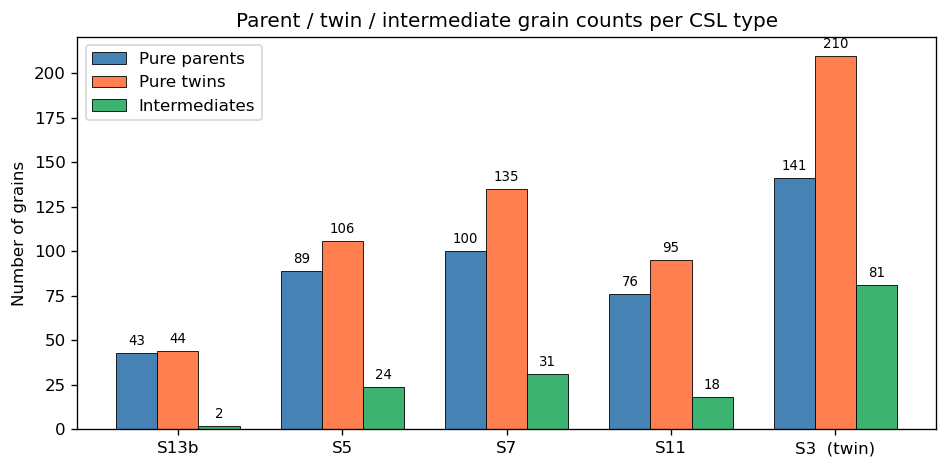

In [10]:
csl_grains = steps_ebsd_analysis_2.segregate_csl_pairs(rg, mdf, peaks, selected_peaks)
parent_info = steps_ebsd_analysis_2.identify_parent_grains(rg, csl_grains)

In [11]:
CSL_LABEL = steps_ebsd_analysis_2.DEFAULT_CSL_LABEL   # 'S3  (twin)'
tvf_by_label = steps_ebsd_analysis_2.compute_twin_area_fractions(rg, parent_info, csl_labels=(CSL_LABEL,))
tvf_by_label[CSL_LABEL]

{'csl_label': 'S3  (twin)',
 'total_area': np.float64(116352.0),
 'pure_parent_frac': np.float64(0.5133388338833883),
 'primary_twin_frac': np.float64(0.13675742574257427),
 'secondary_twin_frac': np.float64(0.048336083608360836),
 'intermediate_frac': np.float64(0.17175467546754675),
 'overall_twin_frac': np.float64(0.35684818481848185),
 'non_role_frac': np.float64(0.12981298129812982),
 'extended_info': {'S13b': {'pairs_labeled': [(25, 15),
    (52, 65),
    (66, 53),
    (69, 78),
    (93, 78),
    (98, 101),
    (131, 152),
    (136, 160),
    (136, 161),
    (147, 232),
    (150, 187),
    (151, 178),
    (157, 152),
    (158, 234),
    (167, 163),
    (170, 169),
    (207, 170),
    (181, 276),
    (215, 186),
    (236, 188),
    (189, 221),
    (209, 222),
    (231, 214),
    (216, 241),
    (291, 225),
    (241, 274),
    (291, 315),
    (329, 304),
    (314, 345),
    (351, 316),
    (319, 345),
    (320, 322),
    (320, 358),
    (337, 323),
    (339, 324),
    (351, 327),
 

In [12]:
role_props = steps_ebsd_analysis_2.compute_grain_role_properties(rg, parent_info, selected_props=('area',))
vf_partition, vf_targets = steps_ebsd_analysis_2.compute_vf_partition(rg, parent_info, tvf_by_label, csl_label=CSL_LABEL)
vf_targets

compute_ebsd_twin_vf_partition  (CSL: S3  (twin))
  Intermediates (primary twins) :   81  VF=0.1718
  Type-2a pure twins (outward)  :  199  VF=0.1807
  Type-2b pure twins (inward)   :   11  VF=0.0044
  SGC Stage-1 carving target    :       VF=0.1762  (intermediate + 2b)
  Derived prob_secondary_outward: 0.976


{'tvf_stage1': np.float64(0.308512101210121),
 'tvf_secondary_2a': np.float64(0.024168041804180418),
 'tvf_secondary_2b': np.float64(0.024168041804180418),
 'prob_secondary_outward': 0.5}

In [13]:
TWIN_THICKNESS_ABRUPT_THRESHOLD = 0.8   # twin-extent/parent-extent ratio below which a twin counts as abruptly-ending
twin_thickness = steps_ebsd_analysis_2.compute_twin_thickness(
    rg, parent_info, abrupt_threshold=TWIN_THICKNESS_ABRUPT_THRESHOLD)
twin_thickness['mean'], twin_thickness['median']

  Twin thickness (minor_axis_length) and intercept statistics (EBSD):
  Metric                              Q1    Q2 (med)        Q3       IQR
  ----------------------------------------------------------------------
  Thickness (µm)                   11.92       16.33     24.00     12.07
  Intercept length (px)             1.00        1.00      5.00      4.00
  Linear intercept (px), X,Y,Z      3.00        8.00     16.25     13.25
  Abrupt twins: 261 / 417  (fraction = 0.633)
  N = 414  |  CV = 0.586  |  skewness = 2.006  |  kurtosis (excess) = 5.706


(19.640914480154372, 16.327818332377632)

In [14]:
report.add_table([vf_targets], title='EBSD VF Targets', section='EBSD Analysis-2')
twin_thickness_summary = {k: v for k, v in twin_thickness.items() if not hasattr(v, '__len__') or isinstance(v, str)}
report.add_table([twin_thickness_summary], title='EBSD Twin Thickness Statistics', section='EBSD Analysis-2')

TableEntry(id=3, timestamp='2026-09-17T00:49:22', title='EBSD Twin Thickness Statistics', columns=['col', 'step_um', 'mean', 'median', 'std', 'min', 'max', 'pct10', 'pct90', 'n_abrupt_ebsd', 'abrupt_frac_ebsd', 'intercept_q1', 'intercept_q2', 'intercept_q3', 'linear_intercept_q1', 'linear_intercept_q2', 'linear_intercept_q3', 'n_twins', 'thick_q1', 'thick_q3', 'skewness', 'kurtosis', 'cv'], rows=[['minor_axis_length', 2.0, 19.640914480154372, 16.327818332377632, 11.514843716806029, 5.563157194476387, 86.26351579373421, 9.196966294519228, 34.199942654757976, 261, 0.633495145631068, 1.0, 1.0, 5.0, 3.0, 8.0, 16.25, 414, 11.922281209038562, 23.996926093381504, 2.0058126991077323, 5.705684439976867, 0.5862682070349061]], caption=None, section='EBSD Analysis-2', source_page=None)

### Pole Figures

Orientation pole figures for the EBSD reference, by population: the full
map, parents only, twins only, and parents and twins overlaid on a single
plot with distinct markers. Multiples-of-uniform-density (MUD) contours
are plotted by default; scatter representation is available via
`plot_mode='scatter'` in `steps_visualization_export.plot_pole_figure()`.
`POLE_FIGURE_HALF_WIDTH_DEG` specifies the angular half-width of the
density kernel: larger values increase smoothing, smaller values reveal
finer local structure at the expense of increased noise.

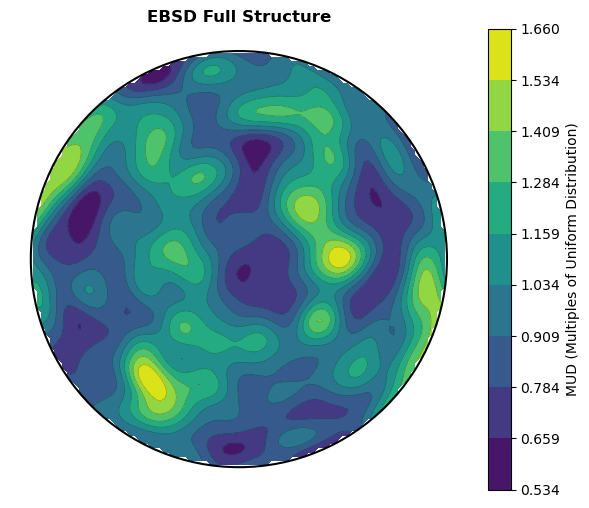

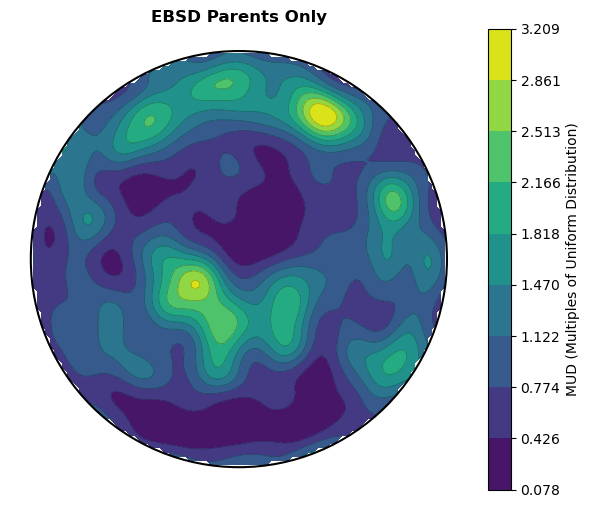

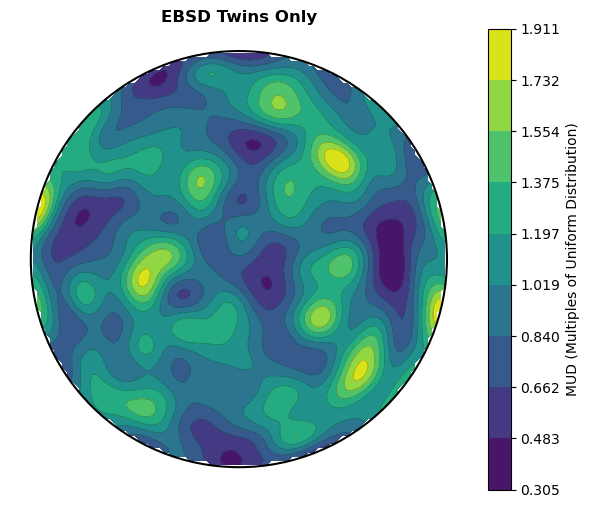

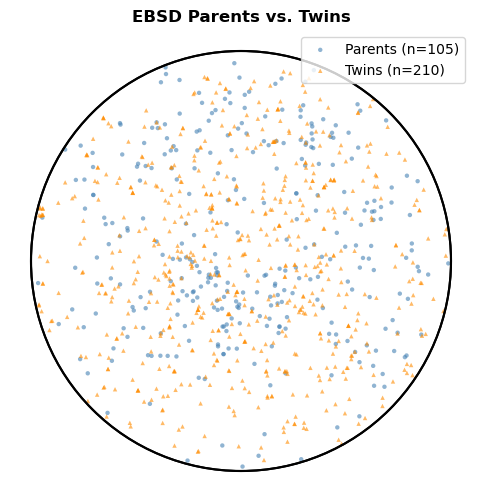

In [15]:
POLE_FIGURE_HALF_WIDTH_DEG = 7.5
POLE_FIGURE_FAMILY = '100'

ebsd_pf_stages = steps_ebsd_analysis_2.ebsd_pole_figure_stages(rg, parent_info, csl_label=CSL_LABEL)

fig, ax = steps_visualization_export.plot_pole_figure(
    ebsd_pf_stages['full'], pole_family=POLE_FIGURE_FAMILY, plot_mode='density',
    half_width_deg=POLE_FIGURE_HALF_WIDTH_DEG, title='EBSD Full Structure')
report.add_image(fig, title='EBSD Pole Figure -- Full Structure', section='EBSD Analysis-2')
plt.show()

fig, ax = steps_visualization_export.plot_pole_figure(
    ebsd_pf_stages['parents'], pole_family=POLE_FIGURE_FAMILY, plot_mode='density',
    half_width_deg=POLE_FIGURE_HALF_WIDTH_DEG, title='EBSD Parents Only')
report.add_image(fig, title='EBSD Pole Figure -- Parents Only', section='EBSD Analysis-2')
plt.show()

fig, ax = steps_visualization_export.plot_pole_figure(
    ebsd_pf_stages['all_twins'], pole_family=POLE_FIGURE_FAMILY, plot_mode='density',
    half_width_deg=POLE_FIGURE_HALF_WIDTH_DEG, title='EBSD Twins Only')
report.add_image(fig, title='EBSD Pole Figure -- Twins Only', section='EBSD Analysis-2')
plt.show()

fig, ax = steps_visualization_export.plot_pole_figure_overlay(
    ebsd_pf_stages['parents'], 'Parents', ebsd_pf_stages['all_twins'], 'Twins',
    pole_family=POLE_FIGURE_FAMILY, title='EBSD Parents vs. Twins')
report.add_image(fig, title='EBSD Pole Figure -- Parents vs Twins Overlay', section='EBSD Analysis-2')
plt.show()

## Part E: Self-Representativeness-3 (Omitted)

Texture and pole-figure analysis for this stage remains unimplemented in
the current package; no functional code exists to wrap. Consistent with
the `twinned_simple_3d` package documentation, which advises against
placeholder implementations for production studies, no
`steps_self_repr_3.py` module or corresponding cell is provided here.

## Part F: Base Grain Structure (Monte Carlo)

Method selection is unambiguous on this path: Monte Carlo is the
base-grain-structure generation method addressed in this notebook,
distinct from the Voronoi and image-import paths, which are not covered
here. Executes a three-dimensional Potts-model Monte Carlo grain-growth
simulation, computes the labelled feature index (grain labels) for every
stored temporal slice, and applies cleaning to each slice (merging
undersized grains, removing single-voxel spikes).

In [16]:
# NOTE: a full 50x50x50, 100-step run can take a while --
# shrink XMAX/YMAX/ZMAX/MCSTEPS for a quick smoke-test run.
pxt = steps_base_grain_structure_mc.run_mc_simulation(
    xmax=50.0, ymax=50.0, zmax=50.0, q_states=10, mcsteps=100, save_interval=5,
    mcalg='300b', consider_boltzmann=True, boltzmann_temp_factor=0.01, rng_seed=0)

Algo_hops details
(('300b', 100),)
[False]
Initiating grain growth
----------------------------------------
GS temporal slice 0 stored
GS temporal slice 5 stored
GS temporal slice 10 stored
GS temporal slice 15 stored
GS temporal slice 20 stored
GS temporal slice 25 stored
GS temporal slice 30 stored
GS temporal slice 35 stored
GS temporal slice 40 stored
GS temporal slice 45 stored
GS temporal slice 50 stored
GS temporal slice 55 stored
GS temporal slice 60 stored
GS temporal slice 65 stored
GS temporal slice 70 stored
GS temporal slice 75 stored
GS temporal slice 80 stored
GS temporal slice 85 stored
GS temporal slice 90 stored
GS temporal slice 95 stored
|--------------- MC SIM RUN COMPLETED on: ALG310---------------|
Number of gs tslices: 20


In [17]:
lfi = steps_base_grain_structure_mc.calculate_lfi(pxt)

---------------------------------------- 
Finding grains.
No. of grains detected = 48101
---------------------------------------- 
Setting PyVista grid.
---------------------------------------- 
Adding scalar field: lgi to PyVista grid self.pvgrid.
Access: self.pvgrid.cell_data['lgi']

Finding voxel locations of grains in lgi.

Finding normal and extended spatial bounds of all grains.
Completed ----------------------------------------
----------------------------------------
---------------------------------------- 
Setting grain volumes (metric: 'volnv') -> 
Grain volumes (metric: 'volnv') -> : have been set.
 ----------------------------------------
  t=0: 48101 grain(s)
---------------------------------------- 
Finding grains.
No. of grains detected = 2052
---------------------------------------- 
Setting PyVista grid.
---------------------------------------- 
Adding scalar field: lgi to PyVista grid self.pvgrid.
Access: self.pvgrid.cell_data['lgi']

Finding voxel locations of grain

In [18]:
cumulative_summary, n_passes_run = steps_base_grain_structure_mc.clean_structure(pxt, min_grain_size=4, start_index=1)
n_passes_run

-- Clean pass 1/5 --
  t=5: merged 1135 small grain(s), removed 4050 spike voxel(s)
  t=10: merged 298 small grain(s), removed 1790 spike voxel(s)
  t=15: merged 170 small grain(s), removed 1148 spike voxel(s)
  t=20: merged 142 small grain(s), removed 871 spike voxel(s)
  t=25: merged 96 small grain(s), removed 685 spike voxel(s)
  t=30: merged 79 small grain(s), removed 559 spike voxel(s)
  t=35: merged 58 small grain(s), removed 496 spike voxel(s)
  t=40: merged 39 small grain(s), removed 434 spike voxel(s)
  t=45: merged 49 small grain(s), removed 347 spike voxel(s)
  t=50: merged 46 small grain(s), removed 330 spike voxel(s)
  t=55: merged 31 small grain(s), removed 264 spike voxel(s)
  t=60: merged 49 small grain(s), removed 288 spike voxel(s)
  t=65: merged 29 small grain(s), removed 239 spike voxel(s)
  t=70: merged 35 small grain(s), removed 230 spike voxel(s)
  t=75: merged 34 small grain(s), removed 217 spike voxel(s)
  t=80: merged 37 small grain(s), removed 207 spike voxel

5

## Part G: Representativeness Assessment and Qualification


Ranks every stored Monte Carlo temporal slice against the EBSD
parent-grain reference (two-dimensional cross-sections compared with the
EBSD map), re-assesses candidates under the configured tolerances, and
selects the single best-matching slice as the authoritative structure for
host allocation. The physical scale factor (um/voxel) of the selected
slice is calibrated in the same step.

Ranking begins at slice index 1 rather than 0: slice 0 represents the
Monte Carlo simulation's un-annealed seed state (a grain count equal to
the voxel count, with no growth), which is not a meaningful
synthetic-structure candidate. Its disproportionately large grain count
can otherwise dominate the shortlist under certain criteria despite
representing the poorest overall match. The Base Grain Structure cleaning
step already excludes this slice (`start_index=1`) for the same reason.

`QUAL_NG_TOLERANCE_PCT` and `QUAL_SCALE_CHECK_TOLERANCE_PCT` govern the stringency of the shortlist star-rating: tighter tolerances reduce the number of candidates earning full marks and can alter the selected slice.

In [19]:
QUAL_N_COMPARISON_SLICES = 5          # 2D cross-sections sampled per axis, per candidate slice
QUAL_SCALE_CHECK_TOLERANCE_PCT = 5.0  # allowed drift (%) in the calibrated scale factor across candidates
QUAL_NG_TOLERANCE_PCT = 5.0           # allowed relative deviation (%) in grain count vs. EBSD before a candidate loses a star

candidates = steps_repr_assessment_qualification.rank_slices(
    pxt, parent_info=parent_info, role_props=role_props, start=1,
    n_comparison_slices=QUAL_N_COMPARISON_SLICES,
    scale_check_tolerance_pct=QUAL_SCALE_CHECK_TOLERANCE_PCT)
len(candidates)

  [1/19] tslice=5 ...  2D-avg grains=127.1 (n_slices=15, ratio=0.90)  3D grains=844 (face=493, interior=351)  |  pooled: area(n=1907)
  [2/19] tslice=10 ...  2D-avg grains=92.7 (n_slices=15, ratio=0.66)  3D grains=550 (face=359, interior=191)  |  pooled: area(n=1390)
  [3/19] tslice=15 ...  2D-avg grains=75.1 (n_slices=15, ratio=0.53)  3D grains=415 (face=281, interior=134)  |  pooled: area(n=1127)
  [4/19] tslice=20 ...  2D-avg grains=62.7 (n_slices=15, ratio=0.44)  3D grains=328 (face=227, interior=101)  |  pooled: area(n=941)
  [5/19] tslice=25 ...  2D-avg grains=54.8 (n_slices=15, ratio=0.39)  3D grains=276 (face=199, interior=77)  |  pooled: area(n=822)
  [6/19] tslice=30 ...  2D-avg grains=48.3 (n_slices=15, ratio=0.34)  3D grains=227 (face=168, interior=59)  |  pooled: area(n=725)
  [7/19] tslice=35 ...  2D-avg grains=43.9 (n_slices=15, ratio=0.31)  3D grains=195 (face=145, interior=50)  |  pooled: area(n=658)
  [8/19] tslice=40 ...  2D-avg grains=40.7 (n_slices=15, ratio=0.29) 

19

In [20]:
candidates = steps_repr_assessment_qualification.reassess_candidates(
    pxt, candidates, role_props, scale_check_tolerance_pct=QUAL_SCALE_CHECK_TOLERANCE_PCT)

In [21]:
QUAL_SHORTLIST_CONFIG = {
    'MC_NG_TOLERANCE_PCT': QUAL_NG_TOLERANCE_PCT,
    'MC_PROPERTY_TOLERANCE_PCT_PER_PROP': {},
    'MC_SCALE_CHECK_TOLERANCE_PCT': QUAL_SCALE_CHECK_TOLERANCE_PCT,
}
rows, best_row = steps_repr_assessment_qualification.shortlist_and_select(
    candidates, role_props, config=QUAL_SHORTLIST_CONFIG)
best_row['tslice_key'] if best_row else None

5

In [22]:
scale_factor = steps_repr_assessment_qualification.apply_selected_scale_factor(pxt, best_row)
tslice_key = best_row['tslice_key']
scale_factor

4.003456830962983

In [23]:
report.add_table([rows[0]] if rows else [{}], title='Temporal Slice Shortlist', section='Repr. assess. & qualification')

TableEntry(id=9, timestamp='2026-09-17T00:49:34', title='Temporal Slice Shortlist', columns=['tslice_key', 'n_stars', 'aggregate_score', 'scale_factor', 'implied_rve_size_um', 'star_rank', 'score_rank', 'coupled_rank'], rows=[[5, 1, 0.9121742015347947, 4.003456830962983, (204.17629837911213, 204.17629837911213, 204.17629837911213), 1, 1, 1]], caption=None, section='Repr. assess. & qualification', source_page=None)

## Part H: Transformations (Optional)

All scaling factors default to 1.0 (identity; no modification applied).
This cell may be skipped entirely, in which case the selected temporal
slice's base structure proceeds unmodified; executing it rescales and
stretches the structure (introducing non-equiaxiality) prior to host
allocation.

In [24]:
SCALE_FACTOR, SF_X, SF_Y, SF_Z = 1.0, 1.0, 1.0, 1.0   # identity -- no transform
transformed_base, original_base = steps_transformations.apply_transform(
    pxt, tslice_key, scale_factor=SCALE_FACTOR, sf_x=SF_X, sf_y=SF_Y, sf_z=SF_Z)

## Part I: Host Allocation


Allocates which grains within the base structure become twin "hosts", via
a maximal-independent-set-constrained spatial selection targeting a
specified volume fraction, then re-assesses the result through
two-dimensional cross-sections for comparability with the EBSD
two-dimensional hosting-fraction target.

`HOST_TARGET_FRACTION` is a grain-count fraction, derived from EBSD's
`twin_hosting_fraction` (the fraction of parent grains hosting a twin),
not an area or volume fraction; the achieved hosting fraction reported
below is, by contrast, a volume fraction, and the two quantities are
therefore not directly comparable. The volume captured by a given
grain-count selection depends strongly on `HOST_RANKING_VOLUME_WEIGHT` and
`HOST_POOL_B_BAND_SHAPE`: ranking purely by volume (1.0) and drawing Pool
B from the large-grain tail (`'above'`), as configured here, biases
selection toward larger grains, such that a moderate grain-count fraction
can capture a disproportionate share of total volume on a right-skewed
grain-size distribution.

In [25]:
HOST_TARGET_FRACTION = 0.3          # EBSD 2D hosting fraction (grain-count based)
HOST_MIN_VOXELS = 4                 # grains smaller than this are never host-eligible
HOST_2D_TO_3D_SCALE_FACTOR = 1.65   # corrects 2D EBSD under-sampling of the true 3D hosting fraction
HOST_RANKING_VOLUME_WEIGHT = 1.0    # 0=rank by adjacency count, 1=rank by volume (largest first), 0.5=equal blend
HOST_MIS_FRACTION = 0.25            # fraction of hosts drawn from the non-adjacent (MIS) pool
HOST_MIS_RUNS = 10                  # number of random MIS trials; the largest is kept
HOST_SEED = 0
HOST_POOL_B_BAND_SHAPE = 'above'    # 'below'/'between'/'above' -- which size-tail Pool B draws from
HOST_POOL_B_N_STD = 1.0             # Pool B band half-width, in std devs of grain size

base = steps_host_allocation.allocate_hosts(
    pxt, tslice_key, transformed_base=transformed_base,   # None to use the raw MC slice instead
    target_fraction=HOST_TARGET_FRACTION, min_voxels=HOST_MIN_VOXELS,
    scale_factor=HOST_2D_TO_3D_SCALE_FACTOR, ranking_weight=HOST_RANKING_VOLUME_WEIGHT,
    mis_fraction=HOST_MIS_FRACTION, mis_runs=HOST_MIS_RUNS, seed=HOST_SEED,
    pool_b_band_shape=HOST_POOL_B_BAND_SHAPE, pool_b_n_std=HOST_POOL_B_N_STD)

TwinnedSimple3DBase.allocate_twin_hosts_spatial:
  EBSD 2D hosting fraction   : 0.3000
  3D effective target        : 0.4950
  n_target                   : 418
  MIS best size              : 253  (from 10 runs, seed base 0)
  Pool A (MIS, 25%)         : 104 grains
  Pool B size measure        : vol_vox  (grain volume in voxels)
  Pool B band                : +/-1 std, shape=above  (mean=157  std=339  band [-182, inf])
  Pool B candidates          : 740 do-neighbour, 0 do-not-neighbour
  Pool B neighbour fraction  : 50%  (314 from do-neighbour, 0 from do-not)
  Pool B (in-band)           : 314 grains selected
  Total hosts                : 418
  Non-host grains            : 426
  Achieved hosting fraction  : 0.9168


In [26]:
hosting_2d = steps_host_allocation.reassess_hosting_2d(base)
hosting_2d

{'count_ratio_mean': 0.7203905751095951,
 'count_ratio_std': 0.09775101693037373,
 'area_ratio_mean': 0.8752531077790593,
 'area_ratio_std': 0.073718089542343,
 'n_slices_used': 15,
 'per_slice': [{'axis': 'x',
   'location': 0,
   'count_ratio': 0.5317460317460317,
   'area_ratio': 0.7351018838908112,
   'n_host_2d': 67,
   'n_eligible_2d': 126},
  {'axis': 'x',
   'location': 12,
   'count_ratio': 0.7916666666666666,
   'area_ratio': 0.922722029988466,
   'n_host_2d': 95,
   'n_eligible_2d': 120},
  {'axis': 'x',
   'location': 25,
   'count_ratio': 0.7833333333333333,
   'area_ratio': 0.9307958477508651,
   'n_host_2d': 94,
   'n_eligible_2d': 120},
  {'axis': 'x',
   'location': 37,
   'count_ratio': 0.795774647887324,
   'area_ratio': 0.9246443675509419,
   'n_host_2d': 113,
   'n_eligible_2d': 142},
  {'axis': 'x',
   'location': 50,
   'count_ratio': 0.6206896551724138,
   'area_ratio': 0.8054594386774317,
   'n_host_2d': 72,
   'n_eligible_2d': 116},
  {'axis': 'y',
   'locatio

In [27]:
report.add_table([hosting_2d], title='Host Allocation 2D Re-Assessment', section='Host Allocation')

TableEntry(id=11, timestamp='2026-09-17T00:49:35', title='Host Allocation 2D Re-Assessment', columns=['count_ratio_mean', 'count_ratio_std', 'area_ratio_mean', 'area_ratio_std', 'n_slices_used', 'per_slice'], rows=[[0.7203905751095951, 0.09775101693037373, 0.8752531077790593, 0.073718089542343, 15, [{'axis': 'x', 'location': 0, 'count_ratio': 0.5317460317460317, 'area_ratio': 0.7351018838908112, 'n_host_2d': 67, 'n_eligible_2d': 126}, {'axis': 'x', 'location': 12, 'count_ratio': 0.7916666666666666, 'area_ratio': 0.922722029988466, 'n_host_2d': 95, 'n_eligible_2d': 120}, {'axis': 'x', 'location': 25, 'count_ratio': 0.7833333333333333, 'area_ratio': 0.9307958477508651, 'n_host_2d': 94, 'n_eligible_2d': 120}, {'axis': 'x', 'location': 37, 'count_ratio': 0.795774647887324, 'area_ratio': 0.9246443675509419, 'n_host_2d': 113, 'n_eligible_2d': 142}, {'axis': 'x', 'location': 50, 'count_ratio': 0.6206896551724138, 'area_ratio': 0.8054594386774317, 'n_host_2d': 72, 'n_eligible_2d': 116}, {'axis

### Grain Structure Summary

Reports overall grain-count and volume statistics for the allocated base
structure, together with a host-versus-non-host volume breakdown,
providing quantitative context for the hosting fraction targeted
above.

In [28]:
vols = np.array(list(base.mprop['volnv'].values()))
host_vols = np.array([base.mprop['volnv'][g] for g in base.host_grain_ids])
nonhost_vols = np.array([base.mprop['volnv'][g] for g in base.non_host_grain_ids])

print(f'Base structure: {len(vols)} grains total')
print(f'  Volume (voxels)  mean={vols.mean():.1f}  median={np.median(vols):.1f}  '
      f'min={vols.min():.0f}  max={vols.max():.0f}')
print()
print(f'Host grains:     {len(host_vols)}  '
      f'mean_vol={host_vols.mean():.1f} vox  median_vol={np.median(host_vols):.1f} vox')
print(f'Non-host grains: {len(nonhost_vols)}  '
      f'mean_vol={nonhost_vols.mean():.1f} vox  median_vol={np.median(nonhost_vols):.1f} vox')

Base structure: 844 grains total
  Volume (voxels)  mean=157.2  median=55.0  min=6  max=5158

Host grains:     418  mean_vol=290.9 vox  median_vol=146.0 vox
Non-host grains: 426  mean_vol=25.9 vox  median_vol=21.0 vox


## Part J: Pre-Twin Validation


Validates the grain-size distribution of the host-allocated base structure
against the EBSD twin-merged reference (twins merged into their parent
grain, as the base structure does not yet contain twins), per axis, via
two-dimensional cross-sections and a Wasserstein-distance pass
threshold.

`PRETWIN_P_PERCENTAGE` specifies the minimum percentage of sampled slices, per axis, that must individually satisfy the Wasserstein-distance criterion for that axis to be accepted; `PRETWIN_WASSERSTEIN_THRESHOLD` specifies the maximum Wasserstein distance between a single slice's grain-size distribution and the EBSD reference for that slice to be classified as passing.

In [29]:
PRETWIN_N_SLICES = (10, 10, 10)              # 2D cross-sections sampled per axis (x, y, z)
PRETWIN_P_PERCENTAGE = (60.0, 60.0, 60.0)    # required per-axis pass rate (%) for that axis to be accepted
PRETWIN_WASSERSTEIN_THRESHOLD = 0.5          # max Wasserstein distance for one slice to count as passing

pre_validator = steps_pre_twin_validation.validate_morphological_representativeness(
    base, rg, parent_info, n_slices=PRETWIN_N_SLICES, test_axes=('x', 'y', 'z'),
    p_percentage=PRETWIN_P_PERCENTAGE, wasserstein_threshold=PRETWIN_WASSERSTEIN_THRESHOLD)
pre_validator.overall_accepted

True

In [30]:
print(pre_validator.report())

3D Representativeness Validation
X-axis: 10/10 (100.0%) [ACCEPTED, threshold 60%]
Y-axis: 10/10 (100.0%) [ACCEPTED, threshold 60%]
Z-axis: 10/10 (100.0%) [ACCEPTED, threshold 60%]

Overall 3D acceptance: YES
Threshold: 60.0% per axis


### Per-Axis Pass Rate

Reports the fraction of tested slices, per axis, that satisfy the
Wasserstein-distance representativeness criterion.

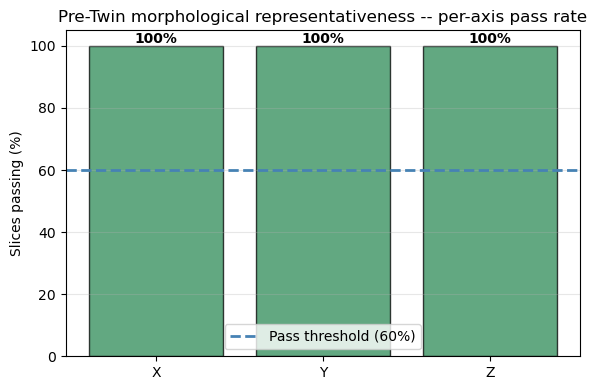

In [31]:
ax_names = list(pre_validator.axis_acceptance.keys())
pct_pass = [pre_validator.axis_acceptance[a]['pct_pass'] for a in ax_names]
colors = ['seagreen' if pre_validator.axis_acceptance[a]['accepted'] else 'crimson' for a in ax_names]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(ax_names, pct_pass, color=colors, alpha=0.75, edgecolor='black')
ax.axhline(60.0, color='steelblue', linestyle='--', linewidth=2, label='Pass threshold (60%)')
ax.set_ylabel('Slices passing (%)')
ax.set_title('Pre-Twin morphological representativeness -- per-axis pass rate')
ax.set_ylim(0, 105)
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar, pct in zip(bars, pct_pass):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'{pct:.0f}%',
            ha='center', va='bottom', fontweight='bold')
plt.tight_layout(); plt.show()

## Part K: Orientation Assignment

Sweeps multiple orientation-assignment mode/seed combinations and scores
each against the real EBSD "pure parents" pole-figure reference, retaining
the best-matching assignment rather than a single, unscored run of
`conflict_free`.

`OPT_SELECTED` specifies which modes to sweep and how many iterations
each (an iterable of `(mode, n_iterations)` pairs); `mrf_gibbs` and
`mrf_map` are available but substantially slower and excluded from the
default selection. Each run's synthetic host-grain pole figure is
compared, grid cell by grid cell, against the EBSD reference (the
CSL-`csl_label` pure-parent grains that, in the EBSD data, always host
this twin type and are never one themselves); runs are ranked by the
interquartile range (IQR) of that cell-by-cell difference, ascending, so
a smaller IQR indicates a tighter, more consistent match across the full
pole figure. `OPT_UNIT_NORMALIZE = True` (default) compares pattern shape
rather than absolute texture strength.

In [32]:
OPT_SELECTED = (('conflict_free', 5), ('paired_pool', 5))   # (mode, n_iterations) pairs to sweep
OPT_BASE_SEED = 42
OPT_POLE_FAMILY = '100'
OPT_RESOLUTION = 'Medium'          # 'Low'/'Medium'/'High' pole-figure grid resolution
OPT_UNIT_NORMALIZE = True

records, top10 = steps_orientation_assignment.optimize_mapping(
    base, rg, parent_info, csl_label=CSL_LABEL, selected=OPT_SELECTED,
    base_seed=OPT_BASE_SEED, pole_family=OPT_POLE_FAMILY, resolution=OPT_RESOLUTION,
    unit_normalize=OPT_UNIT_NORMALIZE)
print(f'{len(records)} successful run(s); {len(top10)} lowest-IQR run(s) retained for inspection.')

Optimize Mapping: EBSD reference built (141 features, 141 orientations, {100}, grid=52, unit_normalize=True)
OrientationAssigner3D: mode = "conflict_free"
.. User texture information standardisation.

Generating orientations for cryst. texture

.. Caclulating TC wise orientation counts
Building TEX dictionary template

.. TEXTURE INSTANCE NUMBER: 1 of 1

.. Generating ori. clusters around mean texture components
Calculating misorientations across all symmetric equivalents of 'brass' texture component: 6072 oris
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 3 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 6 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 9 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 12 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 15 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 18 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 21 of

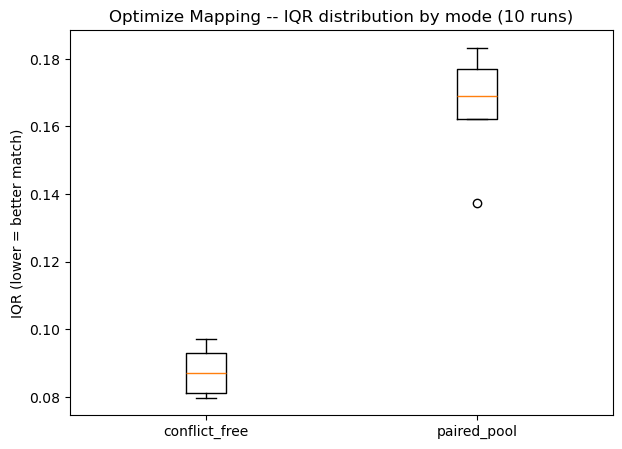

In [33]:
fig, ax = steps_orientation_assignment.plot_optimize_mapping_distribution(records)
report.add_image(fig, title='Optimize Mapping -- IQR Distribution by Mode', section='Orientation Assignment')
plt.show()

In [34]:
assigner = top10[0]['assigner']
print(f"Selected: mode={top10[0]['mode']}  seed={top10[0]['seed']}  "
      f"IQR={top10[0]['iqr']:.4f}  n_conflicts={assigner.n_conflicts}")

optimize_table_rows = [{k: v for k, v in cand.items() if k != 'assigner'} for cand in top10]
report.add_table(optimize_table_rows, title='Optimize Mapping -- Top Candidates', section='Orientation Assignment')

Selected: mode=conflict_free  seed=100042  IQR=0.0798  n_conflicts=0


TableEntry(id=14, timestamp='2026-09-17T00:49:41', title='Optimize Mapping -- Top Candidates', columns=['mode', 'iteration', 'seed', 'csl_label', 'pole_family', 'grid_points', 'unit_normalize', 'min', 'max', 'q25', 'q75', 'iqr', 'n_host'], rows=[['conflict_free', 1, 100042, 'S3  (twin)', '100', 52, True, -0.22795107625277866, 0.18267218941911456, -0.05908225884352564, 0.020710856304302305, 0.07979311514782794, 418], ['conflict_free', 2, 100043, 'S3  (twin)', '100', 52, True, -0.2741287024105347, 0.09134351021563536, -0.11230198209722438, -0.031211750944361377, 0.081090231152863, 418], ['conflict_free', 5, 100046, 'S3  (twin)', '100', 52, True, -0.20616883326814167, 0.18604647456778395, -0.06403956210193934, 0.023098355509404138, 0.08713791761134349, 418], ['conflict_free', 4, 100045, 'S3  (twin)', '100', 52, True, -0.269314104719662, 0.21078867436695026, -0.07119511262375727, 0.021784882914436587, 0.09297999553819386, 418], ['conflict_free', 3, 100044, 'S3  (twin)', '100', 52, True, -0

## Part L: Twin Generation

Introduces primary twins (at host grain-boundary centroids by default),
followed by secondary twins nucleating inward or outward from the primary
twins, targeting the EBSD twin-area fraction measured in Part D. The
resulting structure is then topologically cleaned, removing spike voxels
and splitting non-convex ("lobed") grains produced by the voxel-carving
procedure.

`vf_targets` (Part D) is passed explicitly to this stage; without it,
primary-twin introduction targets the full combined EBSD twin fraction
independently, and secondary-twin introduction is never triggered.
`TWIN_TVF_TOLERANCE` specifies the permitted overshoot beyond the target
volume fraction before introduction halts; `TWIN_PROB_SEC_OUTWARD`/
`TWIN_PROB_SEC_INWARD` specify the 2a (outward, host-interface) versus 2b
(inward, nested within the primary) split for secondary-twin
nucleation.

In [35]:
TWIN_N_LAMELLAE_PER_HOST = 10
TWIN_TVF_TOLERANCE = 0.05          # allowed overshoot past each stage's VF target before stopping
TWIN_TVF_2D_TO_3D_SCALE = 1.15     # fallback only -- unused once vf_targets (staged) is provided
TWIN_THICK_SCALE_FACTOR = 0.80     # scales the EBSD-measured thickness distribution used for lamellae
TWIN_MAX_VF_PER_HOST = 0.50        # cap on twin volume as a fraction of its own host grain's volume
TWIN_PROB_SEC_OUTWARD = 0.60       # secondary-twin nucleation: 2a (outward, at host interface)
TWIN_PROB_SEC_INWARD = 0.40        # secondary-twin nucleation: 2b (inward, nested in primary)
TWIN_RNG_SEED = 123

tg, tvf = steps_twin_generation.generate_twins(
    base, rg, parent_info, assigner, twin_thickness, vf_targets=vf_targets, csl_label=CSL_LABEL,
    n_lamellae_per_host=TWIN_N_LAMELLAE_PER_HOST, nucleation_site='gb_centroid', meshing_route='conformal',
    tvf_tolerance=TWIN_TVF_TOLERANCE, tvf_2d_to_3d_scale=TWIN_TVF_2D_TO_3D_SCALE,
    thick_scale_factor=TWIN_THICK_SCALE_FACTOR, max_vf_per_host=TWIN_MAX_VF_PER_HOST,
    prob_sec_outward=TWIN_PROB_SEC_OUTWARD, prob_sec_inward=TWIN_PROB_SEC_INWARD,
    rng_seed=TWIN_RNG_SEED)
tg.summary()

  [S29] Building grain voxel index... done  844 grains  (0.0s)
TwinGenerator3D NOTE: twin_nucleation_site="gb_centroid" overridden for contacting lamellae (geometric offset).
TwinGenerator3D (primary): 862 twins across 221/418 hosts
  NOTE: VF target reached — introduction stopped early.
TwinGenerator3D NOTE: twin_nucleation_site overridden for outward secondary (interface centroid used).
TwinGenerator3D: secondary stopped — VF target reached.
TwinGenerator3D: secondary twins: 45 (outward 2a: 29, inward 2b: 16)


{'twin_csl_type': 'Sigma3 -- FCC Annealing Twin (60 deg / <111>)',
 'n_lamellae_per_host': 10,
 'twin_nucleation_site': 'gb_centroid',
 'meshing_route': 'conformal',
 'twin_orient_scatter_deg': 1.5,
 'twin_thick_scale_factor': 0.8,
 'tvf_2d_to_3d_scale_factor': 1.15,
 'tvf_tolerance': 0.05,
 'prob_lamella_separated': 0.3,
 'prob_lamella_contacting': 0.7,
 'prob_secondary_outward_twinNucleation': 0.6,
 'prob_secondary_inward_twinNucleation': 0.4,
 'tvf_2d_ebsd': np.float64(0.35684818481848185),
 'tvf_target_3d': 0.308512101210121,
 'tvf_achieved_3d': 0.3500162079441542,
 'tvf_achieved_pct_of_target': 113.45299149408913,
 'vf_stopped_early': True,
 'vf_stop_status': 'Target reached -- introduction capped early',
 'n_host_grains': 418,
 'n_hosts_with_primary_twin': 221,
 'n_primary_twins': 862,
 'n_abrupt_primary': 560,
 'abrupt_frac_mc': 0.6496519721577726,
 'n_clamped': 188,
 'n_twin_halfwidths_recorded': 907,
 'n_secondary_twins': 45,
 'n_all_twin_grains': 907,
 'twin_volume_fraction':

In [36]:
cleaner, n_passes_run = steps_twin_generation.clean_structure(tg, n_passes=5)
len(cleaner.twin_role_clean), n_passes_run

-- Clean pass 1/5 --
[S30] StructureCleaner3D  domain=51x51x51  active_vox=132,651  min_clean_vox=0
  [S30] Step 1/2  Spike removal...  done  6194 spikes  (0.0s)
  [S30] Step 2/2  Lobe splitting...  done  1022 splits  skipped 0 small grains  (0.3s)
StructureCleaner3D: WARNING — 2068 spikes, 0 multi-component grains remain.
-- Clean pass 2/5 --
[S30] StructureCleaner3D  domain=51x51x51  active_vox=132,651  min_clean_vox=0
  [S30] Step 1/2  Spike removal...  done  1508 spikes  (0.0s)
  [S30] Step 2/2  Lobe splitting...  done  61 splits  skipped 0 small grains  (0.0s)
StructureCleaner3D: WARNING — 1332 spikes, 0 multi-component grains remain.
-- Clean pass 3/5 --
[S30] StructureCleaner3D  domain=51x51x51  active_vox=132,651  min_clean_vox=0
  [S30] Step 1/2  Spike removal...  done  626 spikes  (0.0s)
  [S30] Step 2/2  Lobe splitting...  done  17 splits  skipped 0 small grains  (0.0s)
StructureCleaner3D: WARNING — 1161 spikes, 0 multi-component grains remain.
-- Clean pass 4/5 --
[S30] Str

(2859, 5)

## Part M: Post-Twin Validation


Validates the misorientation distribution of the cleaned, twinned
structure against the full EBSD MDF (twins now present, in contrast to
Pre-Twin Validation), per axis, and compares the full three-dimensional
MDF curve directly against the EBSD reference curve computed in
Part D.

`POSTTWIN_P_PERCENTAGE`/`POSTTWIN_WASSERSTEIN_THRESHOLD` define this stage's own pass-rate and distance thresholds, set less stringently than those of Pre-Twin Validation by default, since crystallographic slice-to-slice variation is inherently wider than the grain-size variation assessed in Pre-Twin Validation.

In [37]:
POSTTWIN_N_SLICES = (10, 10, 10)
POSTTWIN_P_PERCENTAGE = 60.0             # required per-axis pass rate (%)
POSTTWIN_WASSERSTEIN_THRESHOLD = 5.0     # max Wasserstein distance for one slice to count as passing

post_validator, quat_3d_clean = steps_post_twin_validation.validate_crystallographic_representativeness(
    cleaner, mdf, n_slices=POSTTWIN_N_SLICES, test_axes=('x', 'y', 'z'),
    p_percentage=POSTTWIN_P_PERCENTAGE, wasserstein_threshold=POSTTWIN_WASSERSTEIN_THRESHOLD)
post_validator.overall_accepted

True

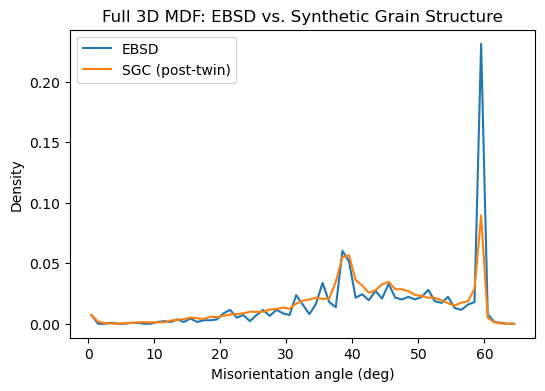

In [38]:
mc_mdf_post = steps_post_twin_validation.compare_full_3d_mdf(cleaner, quat_3d_clean)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(mdf['hist_bin_centers'], mdf['hist_density'], label='EBSD')
ax.plot(mc_mdf_post['hist_bin_centers'], mc_mdf_post['hist_density'], label='SGC (post-twin)')
ax.set_xlabel('Misorientation angle (deg)'); ax.set_ylabel('Density'); ax.legend()
ax.set_title('Full 3D MDF: EBSD vs. Synthetic Grain Structure')
report.add_image(fig, title='Post-Twin Full 3D MDF', section='Post-Twin Validation')
plt.show()

### Per-Axis Pass Rate

Reports the fraction of tested slices, per axis, that satisfy the
Wasserstein-distance representativeness criterion, relative to the pass
threshold specified above.

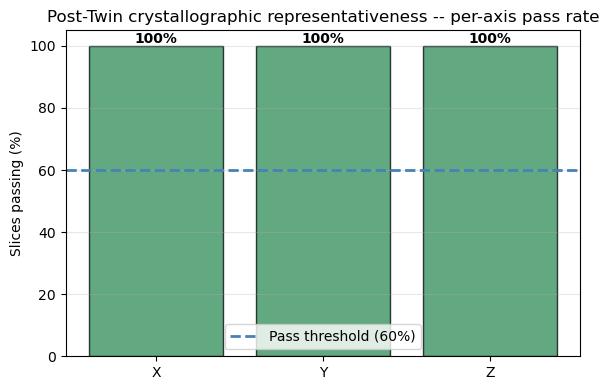

In [39]:
ax_names = list(post_validator.axis_acceptance.keys())
pct_pass = [post_validator.axis_acceptance[a]['pct_pass'] for a in ax_names]
colors = ['seagreen' if post_validator.axis_acceptance[a]['accepted'] else 'crimson' for a in ax_names]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(ax_names, pct_pass, color=colors, alpha=0.75, edgecolor='black')
ax.axhline(60.0, color='steelblue', linestyle='--', linewidth=2, label='Pass threshold (60%)')
ax.set_ylabel('Slices passing (%)')
ax.set_title('Post-Twin crystallographic representativeness -- per-axis pass rate')
ax.set_ylim(0, 105)
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar, pct in zip(bars, pct_pass):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'{pct:.0f}%',
            ha='center', va='bottom', fontweight='bold')
plt.tight_layout(); plt.show()

### Representative-Slice MDF versus EBSD

Plots the MDF of every slice satisfying the criterion above (thin lines)
together with their per-axis mean (bold), against the full EBSD MDF,
illustrating the misorientation characteristics of a representative
two-dimensional section.

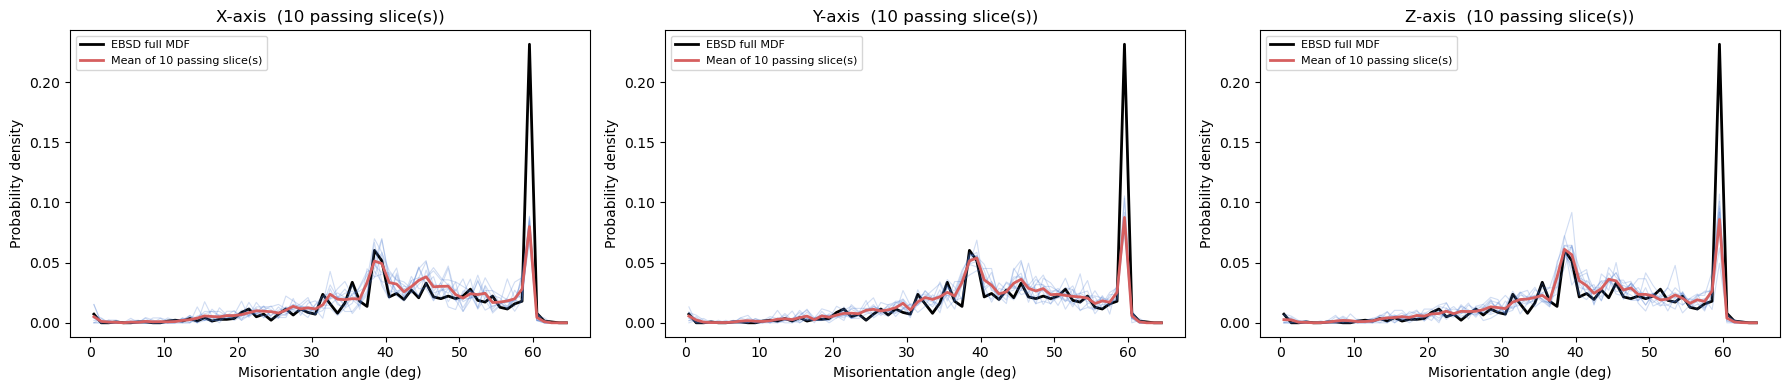

In [40]:
axes_present = [a for a in post_validator.slice_results if post_validator.slice_results[a]]
per_axis_mdf = steps_post_twin_validation.representative_slice_mdfs(
    post_validator, cleaner, quat_3d_clean, axes=axes_present)

fig, axs = plt.subplots(1, len(axes_present), figsize=(6 * len(axes_present), 4), squeeze=False)
for col, axis_name in enumerate(axes_present):
    ax = axs[0][col]
    ax.plot(mdf['hist_bin_centers'], mdf['hist_density'], 'k-', lw=2.0, label='EBSD full MDF')
    info = per_axis_mdf[axis_name]
    for slice_mdf in info['slice_mdfs']:
        ax.plot(slice_mdf['hist_bin_centers'], slice_mdf['hist_density'],
                color='#4878CF', alpha=0.25, lw=0.8)
    if info['mean_density'] is not None:
        ax.plot(info['mean_bin_centers'], info['mean_density'], color='#D65F5F', lw=2.0,
                label=f"Mean of {len(info['slice_mdfs'])} passing slice(s)")
    ax.set_title(f"{axis_name}-axis  ({info['n_passing']} passing slice(s))")
    ax.set_xlabel('Misorientation angle (deg)'); ax.set_ylabel('Probability density')
    ax.legend(fontsize=8)
fig.tight_layout()
report.add_image(fig, title='Representative-Slice MDF vs EBSD', section='Post-Twin Validation')
plt.show()

### Twin Thickness: EBSD Target versus Achieved 3D versus Apparent 2D

Compares three populations: the EBSD target thickness distribution, the
actual three-dimensional thickness introduced during twin generation, and
the apparent thickness measurable on a two-dimensional cross-section (the
minor-axis length of each twin's slice profile), quantifying the extent to
which a two-dimensional measurement under- or overestimates the true
three-dimensional lamella thickness.

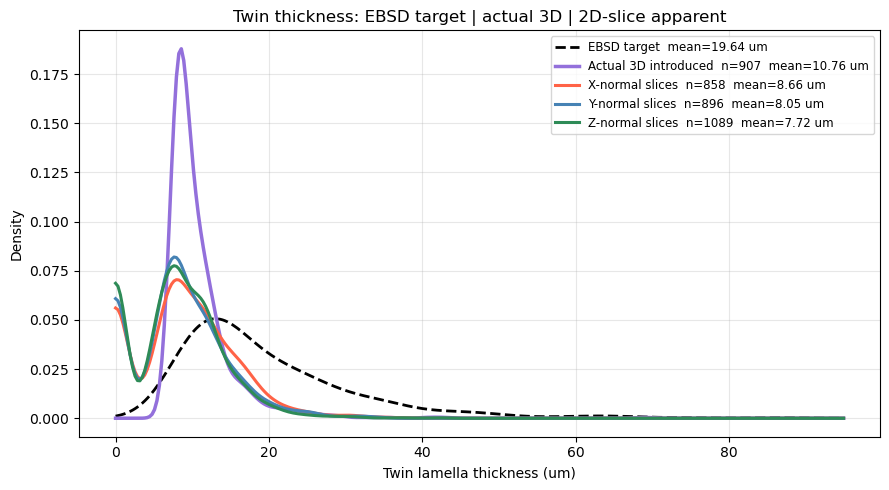

In [41]:
from scipy.stats import gaussian_kde

comparison = steps_post_twin_validation.twin_thickness_three_way_comparison(
    tg, cleaner, twin_thickness, post_validator)
ebsd_um, ebsd_mean_um = comparison['ebsd_um'], comparison['ebsd_mean_um']
actual_3d_um, actual_3d_mean_um = comparison['actual_3d_um'], comparison['actual_3d_mean_um']
per_axis_um, per_axis_means_um = comparison['per_axis_um'], comparison['per_axis_means_um']

all_maxes = [a.max() for a in (ebsd_um, actual_3d_um, *per_axis_um.values()) if a.size]
grid = np.linspace(0, (max(all_maxes) * 1.1) if all_maxes else 1.0, 300)
axis_colors = {'X': 'tomato', 'Y': 'steelblue', 'Z': 'seagreen'}

fig, ax = plt.subplots(figsize=(9, 5))
if ebsd_um.size > 1:
    ax.plot(grid, gaussian_kde(ebsd_um)(grid), 'k--', lw=2,
            label=f'EBSD target  mean={ebsd_mean_um:.2f} um')
if actual_3d_um.size > 1:
    ax.plot(grid, gaussian_kde(actual_3d_um)(grid), color='mediumpurple', lw=2.5,
            label=f'Actual 3D introduced  n={actual_3d_um.size}  mean={actual_3d_mean_um:.2f} um')
for axis_name, values in per_axis_um.items():
    if values.size > 1:
        ax.plot(grid, gaussian_kde(values)(grid), color=axis_colors.get(axis_name, 'gray'), lw=2.2,
                label=f'{axis_name}-normal slices  n={values.size}  mean={per_axis_means_um[axis_name]:.2f} um')
ax.set_xlabel('Twin lamella thickness (um)'); ax.set_ylabel('Density')
ax.set_title('Twin thickness: EBSD target | actual 3D | 2D-slice apparent')
ax.legend(fontsize=8.5); ax.grid(alpha=0.3)
fig.tight_layout()
report.add_image(fig, title='Twin Thickness Three-Way Comparison', section='Post-Twin Validation')
plt.show()

## Part N: Distribution Viewer

Compares the finished synthetic structure against EBSD across four
properties: misorientation, twin lamella thickness, host grain size, and
twin volume fraction, pooled across sampled slices, constituting the
principal test of overall agreement between the synthetic grain structure
(SGS) and the reference EBSD data.

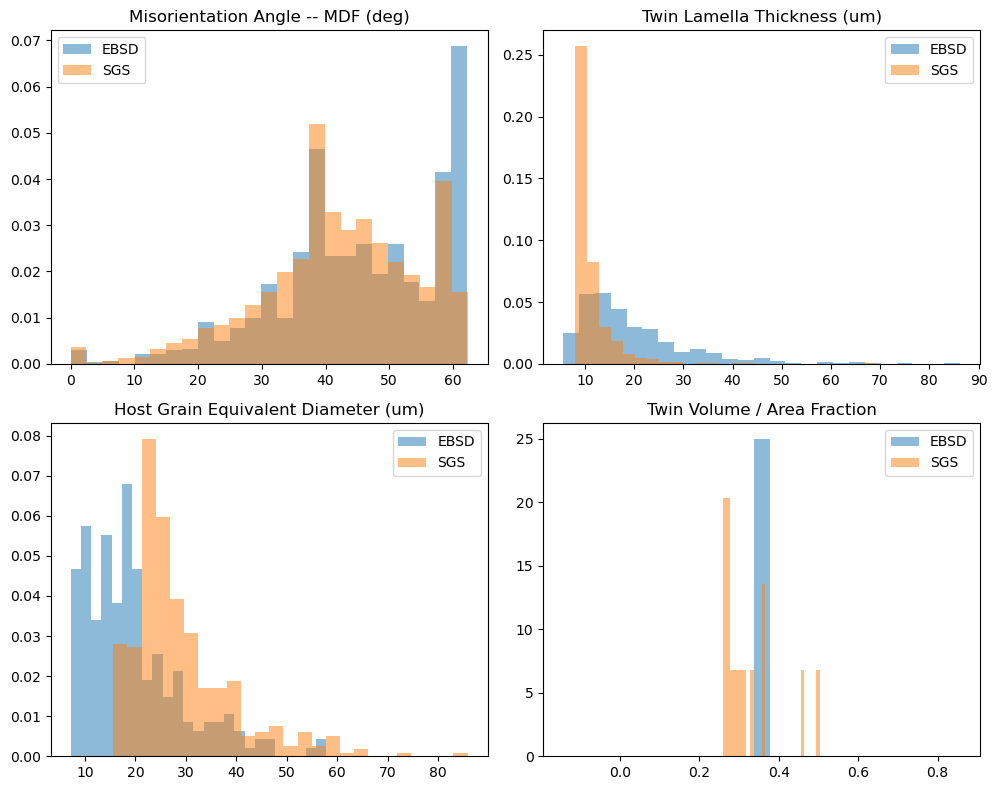

In [42]:
cmp_data = steps_distribution_viewer.compare_ebsd_vs_sgs(
    cleaner, tg, base, rg, parent_info, mdf, twin_thickness, n_per_axis=5)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (prop_name, vals) in zip(axes.ravel(), cmp_data.items()):
    ax.hist(vals['ebsd'], bins=25, alpha=0.5, density=True, label='EBSD')
    ax.hist(vals['sgs'], bins=25, alpha=0.5, density=True, label='SGS')
    ax.set_title(steps_distribution_viewer.COMPARISON_PROP_LABELS[prop_name])
    ax.legend()
fig.tight_layout()
report.add_image(fig, title='EBSD vs. SGS Comparison Properties', section='Distribution Viewer')
plt.show()

### Grain-Role Property Comparison

The comparison above pools all grains together; this analysis instead
stratifies morphology by role: non-hosting matrix grains, host grains, and
twin grains (of any generation), EBSD versus the synthetic structure
(SGS).

The EBSD role taxonomy (pure_parents/pure_twins/intermediates/non_role)
does not correspond one-to-one with that of the synthetic structure
(nonhost/host/primary/seca/secb): an EBSD "intermediate" grain (a twin
that itself hosts a further twin) has no direct synthetic-structure
equivalent, since the primary/secondary distinction in the synthetic
structure reflects nucleation generation rather than whether a twin itself
hosts another twin. Both taxonomies are therefore reduced to three
categories admitting a defensible comparison: non-hosting, host, and twin
(of any generation, on either side).

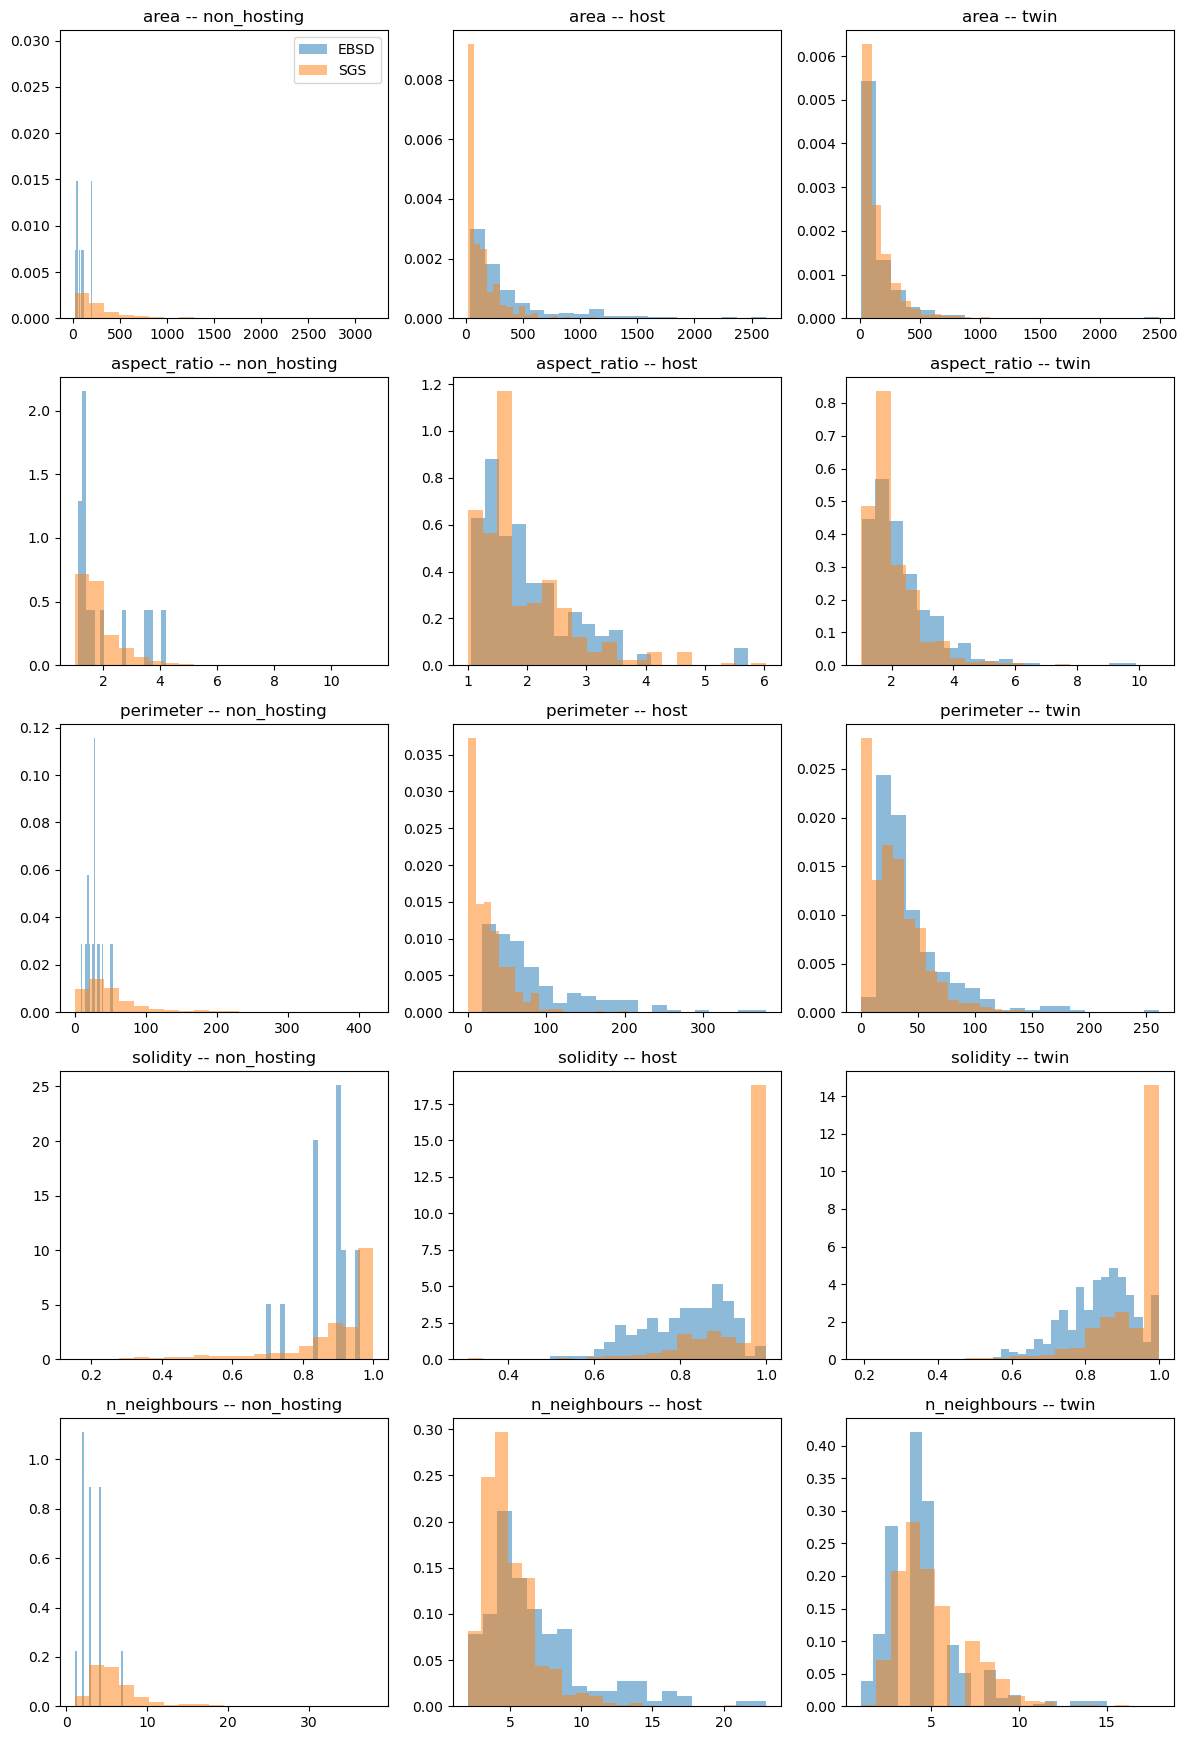

In [43]:
role_prop_data = steps_distribution_viewer.compare_role_properties(
    rg, parent_info, cleaner, voxel_size=base.voxel_size,
    selected_props=('area', 'aspect_ratio', 'perimeter', 'solidity', 'n_neighbours'))

buckets = ['non_hosting', 'host', 'twin']
props_shown = list(role_prop_data.keys())
fig, axes = plt.subplots(len(props_shown), len(buckets),
                          figsize=(4 * len(buckets), 3.5 * len(props_shown)), squeeze=False)
for row, prop in enumerate(props_shown):
    for col, bucket in enumerate(buckets):
        ax = axes[row][col]
        vals = role_prop_data[prop][bucket]
        if vals['ebsd'].size:
            ax.hist(vals['ebsd'], bins=20, alpha=0.5, density=True, label='EBSD')
        if vals['sgs'].size:
            ax.hist(vals['sgs'], bins=20, alpha=0.5, density=True, label='SGS')
        ax.set_title(f'{prop} -- {bucket}')
        if row == 0 and col == 0:
            ax.legend()
fig.tight_layout()
report.add_image(fig, title='Grain-Role Property Comparison (EBSD vs SGS)', section='Distribution Viewer')
plt.show()

## Part O: Subsetting (Optional)

Disabled by default. Extracts one or more cuboidal sub-volumes from the
fully twinned, cleaned three-dimensional structure, for cases requiring a
representative volume element smaller than the full cleaned domain. With
the defaults specified below (a single tile spanning 20% of the domain
from the origin), this stage is effectively a no-op; Visualization and
Export operates correctly on `cleaner` without invoking this stage.

In [44]:
subset_cleaners = steps_subsetting.generate_subsets(
    cleaner, start_pct=(0.0, 0.0, 0.0), n_cuboids=(1, 1, 1),
    length_pct=(20.0, 20.0, 20.0), stride_pct=(20.0, 20.0, 20.0), overflow_policy='clip')
len(subset_cleaners)

1

## Part P: Visualization and Export

Renders the finished three-dimensional structure interactively, writes
the cleaned structure's raw arrays (`.npy`/`.pkl`), and exports a full
Abaqus voxel-conformal mesh (`.inp` files) with element sets by role,
family, and variant, and node sets on each domain face.

In [45]:
# Interactive PyVista render -- opens a separate window (or renders inline
# with a Jupyter PyVista backend enabled). Skip this cell in a headless run.
steps_visualization_export.render_3d_structure(cleaner)

Widget(value='<iframe src="http://localhost:58207/index.html?ui=P_0x221c36be7b0_0&reconnect=auto" class="pyvis…

### IPF-Coloured 2D Slice

An alternative to the interactive three-dimensional render above: a
single two-dimensional cross-section coloured by inverse-pole-figure (IPF)
orientation, rendered with standard matplotlib and displayed inline in any
execution environment.

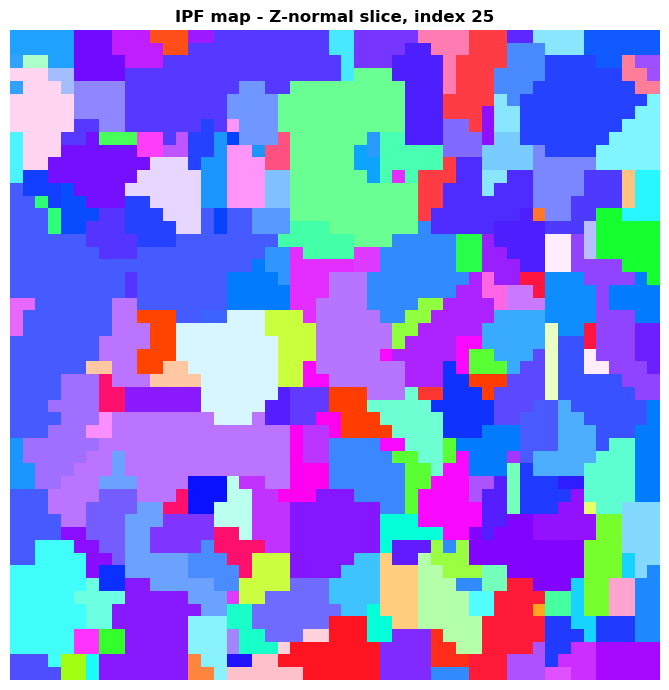

ImageEntry(id=23, timestamp='2026-09-17T00:50:09', title='IPF-Coloured Z-Normal Slice', image_path='assets/0023_ipf_coloured_z_normal_slice.png', caption=None, section='Visualization & Export', source_page=None, params=None)

In [46]:
fig, ax = steps_visualization_export.render_ipf_slice(cleaner, axis=2)
report.add_image(fig, title='IPF-Coloured Z-Normal Slice', section='Visualization & Export')

### Pole Figures

The same four-population set as the EBSD pole figures (Part D), computed
for the final synthetic structure: full structure, host grains only (the
synthetic analogue of EBSD's "parents": every non-twin grain, whether an
allocated host or not), twins only, and hosts and twins overlaid with
distinct markers. `POLE_FIGURE_HALF_WIDTH_DEG` and `POLE_FIGURE_FAMILY`
retain the values specified in Part D.

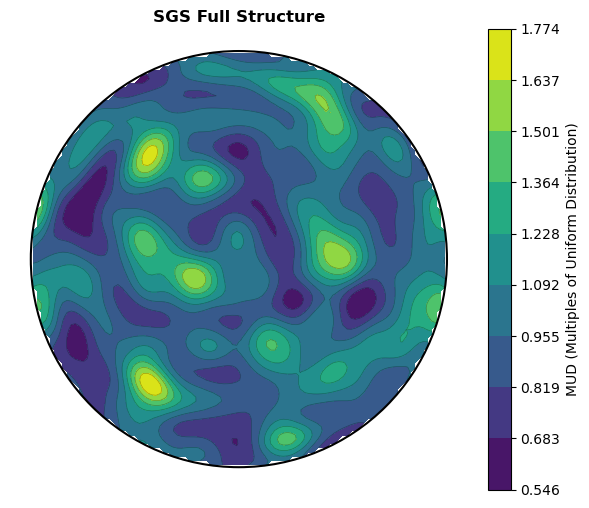

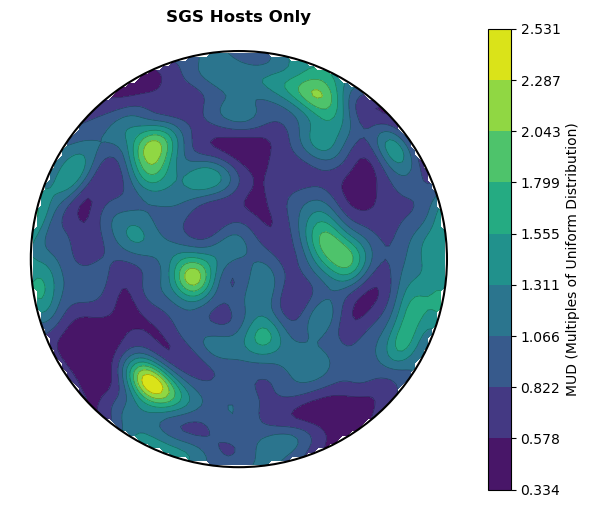

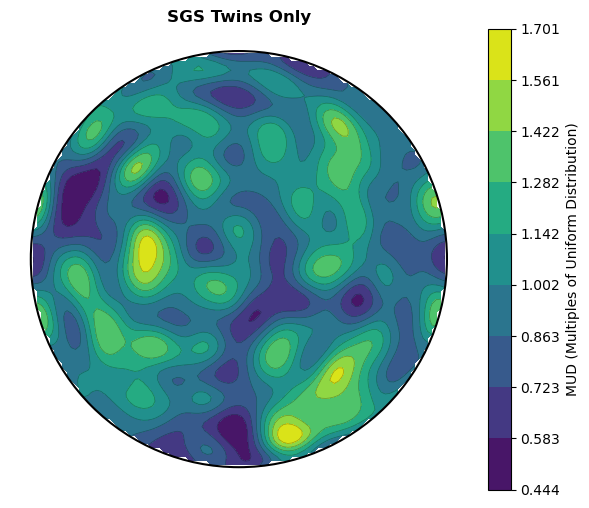

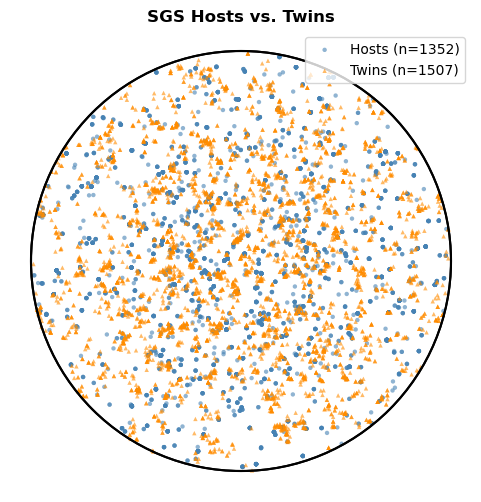

In [47]:
sgs_pf_stages = steps_visualization_export.sgs_pole_figure_stages(cleaner)

fig, ax = steps_visualization_export.plot_pole_figure(
    sgs_pf_stages['full'], pole_family=POLE_FIGURE_FAMILY, plot_mode='density',
    half_width_deg=POLE_FIGURE_HALF_WIDTH_DEG, title='SGS Full Structure')
report.add_image(fig, title='SGS Pole Figure -- Full Structure', section='Visualization & Export')
plt.show()

fig, ax = steps_visualization_export.plot_pole_figure(
    sgs_pf_stages['host'], pole_family=POLE_FIGURE_FAMILY, plot_mode='density',
    half_width_deg=POLE_FIGURE_HALF_WIDTH_DEG, title='SGS Hosts Only')
report.add_image(fig, title='SGS Pole Figure -- Hosts Only', section='Visualization & Export')
plt.show()

fig, ax = steps_visualization_export.plot_pole_figure(
    sgs_pf_stages['all_twins'], pole_family=POLE_FIGURE_FAMILY, plot_mode='density',
    half_width_deg=POLE_FIGURE_HALF_WIDTH_DEG, title='SGS Twins Only')
report.add_image(fig, title='SGS Pole Figure -- Twins Only', section='Visualization & Export')
plt.show()

fig, ax = steps_visualization_export.plot_pole_figure_overlay(
    sgs_pf_stages['host'], 'Hosts', sgs_pf_stages['all_twins'], 'Twins',
    pole_family=POLE_FIGURE_FAMILY, title='SGS Hosts vs. Twins')
report.add_image(fig, title='SGS Pole Figure -- Hosts vs Twins Overlay', section='Visualization & Export')
plt.show()

In [48]:
raw_result = steps_visualization_export.export_raw(cleaner)
raw_result

{'out_dir': 'C:\\Development\\UPXO\\upxo_library\\data\\TwinnedFCC\\Grain Structures\\grain_structure5',
 'master_folder': 'grain_structure5',
 'files': {'lgi_twinned_clean.npy': 530732,
  'orientations_all.pkl': 185870,
  'twin_role.pkl': 14248,
  'twin_parent_of.pkl': 11930},
 'n_grains': 2859,
 'timestamp': '2026-09-17T00:50:15'}

In [49]:
index = steps_visualization_export.build_abaqus_index(cleaner)

AbaqusExporter3D: indexing grain-to-element map...  done (0.1s)  2859 grains


In [50]:
abq_result = steps_visualization_export.export_abaqus_mesh(
    cleaner, tg, index, base_filename='twinned_fcc_mesh', voxel_size_um=1.0,
    element_type='C3D8', material_format='bunge_euler', n_depvar=100,
    material_level='feature')
abq_result

  Writing  01_nodes.inp...  done (0.3s)
  Writing  02_elements.inp...  done (0.5s)
  Writing  03a_elsets_cells.inp...  done (0.1s)
  Writing  03b_elsets_roles.inp...  done (0.1s)
  Writing  03c_elsets_families.inp...  done (0.0s)
  Writing  03d_elsets_variants.inp...  done (0.0s)
  Writing  04_nsets_bc.inp...  done (0.0s)
  Writing  05_materials.inp...  done (0.0s)
  Writing  06_sections.inp...  done (0.0s)
  Writing  07_interactions.inp...  done (0.0s)
  Writing  08_steps_output.inp...  done (0.0s)
AbaqusExporter3D.write: complete  total=1.1s
  Output: C:\Development\UPXO\upxo_library\data\TwinnedFCC\ABQInputFiles\twinned_fcc_mesh62


C:\Development\UPXO\upxo_library\src\upxo\pxtal\twinned_simple_3d\abaqus_exporter_3d.py:398: UserWarning: es_variant_ptwin_<v> ELSETs use a round-robin placeholder, not the real Sigma3 {111} variant selected during twin generation (that index is not currently persisted per grain) -- do not assign variant-specific material behaviour based on this grouping.
  writer(f)
C:\Development\UPXO\upxo_library\src\upxo\demos\Twinned3D\steps\steps_visualization_export.py:280: UserWarning: 07_interactions.inp contains no interaction/constraint definitions (cohesive zone, contact, etc.) -- this .inp is not simulation-ready as exported and must be edited before submission.
  exporter.write(str(out_dir))
C:\Development\UPXO\upxo_library\src\upxo\demos\Twinned3D\steps\steps_visualization_export.py:280: UserWarning: 08_steps_output.inp contains no *Step/boundary-condition/*Output definitions -- this .inp is not simulation-ready as exported and must be edited before submission.
  exporter.write(str(out_d

{'output_dir': 'C:\\Development\\UPXO\\upxo_library\\data\\TwinnedFCC\\ABQInputFiles\\twinned_fcc_mesh62',
 'n_elements': 132651,
 'n_elsets': 2866,
 'n_nsets': 6,
 'files': {'01_nodes.inp': 2619981,
  '02_elements.inp': 7681228,
  '03a_elsets_cells.inp': 1047789,
  '03b_elsets_roles.inp': 1317687,
  '03c_elsets_families.inp': 435830,
  '03d_elsets_variants.inp': 237487,
  '04_nsets_bc.inp': 114894,
  '05_materials.inp': 521583,
  '06_sections.inp': 215163,
  '07_interactions.inp': 87,
  '08_steps_output.inp': 107,
  'model_master.inp': 654}}

In [51]:
abq_summary = {k: v for k, v in abq_result.items() if k != 'files'}
report.add_table([abq_summary], title='Abaqus Mesh Export', section='Visualization & Export')

TableEntry(id=28, timestamp='2026-09-17T00:50:17', title='Abaqus Mesh Export', columns=['output_dir', 'n_elements', 'n_elsets', 'n_nsets'], rows=[['C:\\Development\\UPXO\\upxo_library\\data\\TwinnedFCC\\ABQInputFiles\\twinned_fcc_mesh62', 132651, 2866, 6]], caption=None, section='Visualization & Export', source_page=None)

## Summary: Achieved versus Target Total Twin Volume Fraction

Reports the fraction of the final, cleaned structure's volume occupied by
twin material (primary and secondary combined), relative to the full
EBSD-partitioned target (Stage-1 + Secondary-2a + Secondary-2b from
`vf_targets`, Part D). The comparison is evaluated on `cleaner`, not `tg`,
since cleaning (spike removal, lobe splitting) alters voxel counts
following twin introduction. The value
`tg.summary()['tvf_achieved_pct_of_target']`, reported above, does not
represent this quantity: it compares the pre-cleaning, all-twins-combined
volume against `tvf_target_3d`, the Stage-1-only target used as the
stopping threshold by `introduce_primary_twins`, rather than the combined
total, and consequently reads higher than the true achieved fraction once
secondary twins are included.

In [52]:
twin_gids = {g for g, role in cleaner.twin_role_clean.items()
             if role in ('primary_twin', 'secondary_twin')}
twin_vox = int(np.isin(cleaner.lgi_clean, list(twin_gids)).sum())
total_vox = int(np.sum(cleaner.lgi_clean > 0))
achieved_total_vf = twin_vox / total_vox if total_vox > 0 else 0.0

target_total_vf = (vf_targets['tvf_stage1'] + vf_targets['tvf_secondary_2a']
                    + vf_targets['tvf_secondary_2b'])
pct_of_target = 100 * achieved_total_vf / target_total_vf if target_total_vf > 0 else 0.0

print(f'Target total twin VF (EBSD-partitioned, 3D) : {target_total_vf:.4f}')
print(f'Achieved total twin VF (cleaned structure)   : {achieved_total_vf:.4f}')
print(f'Achieved / Target                            : {pct_of_target:.1f}%')

report.add_table(
    [{'target_total_vf': target_total_vf, 'achieved_total_vf': achieved_total_vf,
      'pct_of_target': pct_of_target}],
    title='Achieved vs. Target Total Twin Volume Fraction', section='Twin Generation')

Target total twin VF (EBSD-partitioned, 3D) : 0.3568
Achieved total twin VF (cleaned structure)   : 0.3431
Achieved / Target                            : 96.2%


TableEntry(id=30, timestamp='2026-09-17T00:50:17', title='Achieved vs. Target Total Twin Volume Fraction', columns=['target_total_vf', 'achieved_total_vf', 'pct_of_target'], rows=[[np.float64(0.35684818481848185), 0.34314856276997535, np.float64(96.16093828374801)]], caption=None, section='Twin Generation', source_page=None)

## Texture and Misorientation Representativeness

The preceding checks (Pre-Twin Validation, Post-Twin Validation, twin
volume fraction) report whether the structure satisfies pre-specified
thresholds. The three metrics that follow report continuous, unthresholded
quantities for two properties not directly assessed by those checks:
crystallographic texture (the distribution of absolute grain orientations,
as distinct from neighbour-pair misorientation) and an aggregate
neighbour-misorientation agreement score. No pass/fail criterion is
established for any of the three, as no corresponding threshold exists
elsewhere in the pipeline; the achieved values are reported for
independent evaluation.

In [53]:
REPR_MATCH_TOLERANCE_PCT = 25.0   # acceptance band (+/- %) applied to morphology/thickness mean ratios below

mdf_repr = steps_post_twin_validation.mdf_representativeness_score(mdf, mc_mdf_post)
mdf_repr_score = mdf_repr['representativeness_score'] if mdf_repr else None

twin_thick_repr = steps_post_twin_validation.twin_thickness_representativeness_score(comparison)
twin_thick_repr_score = twin_thick_repr['representativeness_score'] if twin_thick_repr else None
twin_thick_repr_ratio = twin_thick_repr['ratio'] if twin_thick_repr else None
twin_thick_accepted = (twin_thick_repr_ratio is not None
                        and abs(twin_thick_repr_ratio - 1.0) <= REPR_MATCH_TOLERANCE_PCT / 100.0)

texture_vf_comparison = steps_distribution_viewer.compute_texture_component_vf_comparison(rg, cleaner)
pf_delta_mud = steps_distribution_viewer.compute_pole_figure_delta_mud_iqr(rg, cleaner)
role_prop_summary = steps_distribution_viewer.role_property_match_summary(
    role_prop_data, tolerance_pct=REPR_MATCH_TOLERANCE_PCT)

print('Neighbour misorientation (MDF) representativeness score  :',
      f'{mdf_repr_score:.3f}  (0-1, higher = more alike)' if mdf_repr_score is not None else 'N/A')
print('Twin thickness (EBSD target vs. achieved 3D)              :',
      (f'ratio={twin_thick_repr_ratio:.2f}  score={twin_thick_repr_score:.3f}  '
       f"{'ACCEPTED' if twin_thick_accepted else 'outside tolerance'}")
      if twin_thick_repr_ratio is not None else 'N/A')
print('Texture component VF total deviation                      :',
      f"{texture_vf_comparison['total_abs_deviation_pct']:.1f} pp across "
      f"{len(texture_vf_comparison['matched'])} matched components")
print('Pole figure {100} delta-MUD IQR                            :',
      f"{pf_delta_mud['iqr']:.3f}  (lower = more alike)")
print(f'Grain-role morphology match (tolerance +/-{REPR_MATCH_TOLERANCE_PCT:.0f}%)             :')
for prop, s in role_prop_summary.items():
    tag = 'ACCEPTED' if s['accepted'] else 'outside tolerance'
    ratio_str = f"ratio={s['ratio']:.2f}" if s['ratio'] is not None else 'ratio=N/A'
    score_str = f"score={s['score']:.3f}" if s['score'] is not None else 'score=N/A'
    print(f'    {prop:14s} {ratio_str:14s} {score_str:14s} {tag}')

report.add_table(
    [{'component': m['component'], 'ebsd_vf_pct': m['ebsd_vf_pct'],
      'sgs_vf_pct': m['sgs_vf_pct'], 'abs_diff_pct': m['abs_diff_pct']}
     for m in texture_vf_comparison['matched']] or [{'component': 'none matched'}],
    title='Texture Component Volume-Fraction Comparison', section='Distribution Viewer')

Neighbour misorientation (MDF) representativeness score  : 0.859  (0-1, higher = more alike)
Twin thickness (EBSD target vs. achieved 3D)              : ratio=0.56  score=0.519  outside tolerance
Texture component VF total deviation                      : 0.3 pp across 1 matched components
Pole figure {100} delta-MUD IQR                            : 0.956  (lower = more alike)
Grain-role morphology match (tolerance +/-25%)             :
    area           ratio=1.70     score=0.594    outside tolerance
    aspect_ratio   ratio=0.91     score=0.744    ACCEPTED
    perimeter      ratio=0.84     score=0.601    ACCEPTED
    solidity       ratio=1.12     score=0.264    ACCEPTED
    n_neighbours   ratio=1.19     score=0.565    ACCEPTED


TableEntry(id=32, timestamp='2026-09-17T00:52:25', title='Texture Component Volume-Fraction Comparison', columns=['component', 'ebsd_vf_pct', 'sgs_vf_pct', 'abs_diff_pct'], rows=[['s', 3.3725247524752477, 3.112679135475797, 0.2598456169994505]], caption=None, section='Distribution Viewer', source_page=None)

### Texture Residual Pole Figures

The three-panel EBSD | SGS | Difference pole-figure plot used elsewhere in
this pipeline for comparing two orientation populations. The first panel
set (full structure versus full structure) reproduces the {100}
delta-MUD interquartile range reported above exactly, as it is computed
from the identical populations; the second (parents versus hosts)
provides an additional, twin-role-specific comparison rather than a
pooled one.

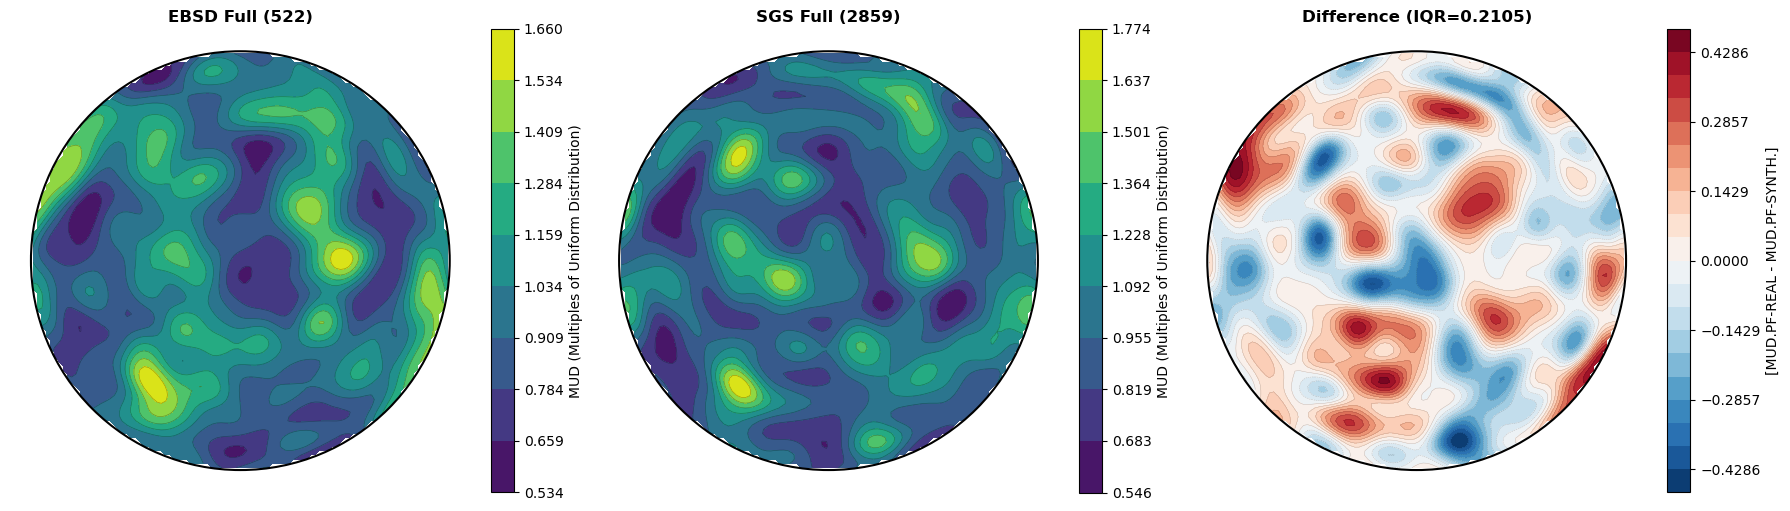

Full-structure delta-MUD IQR: 0.211


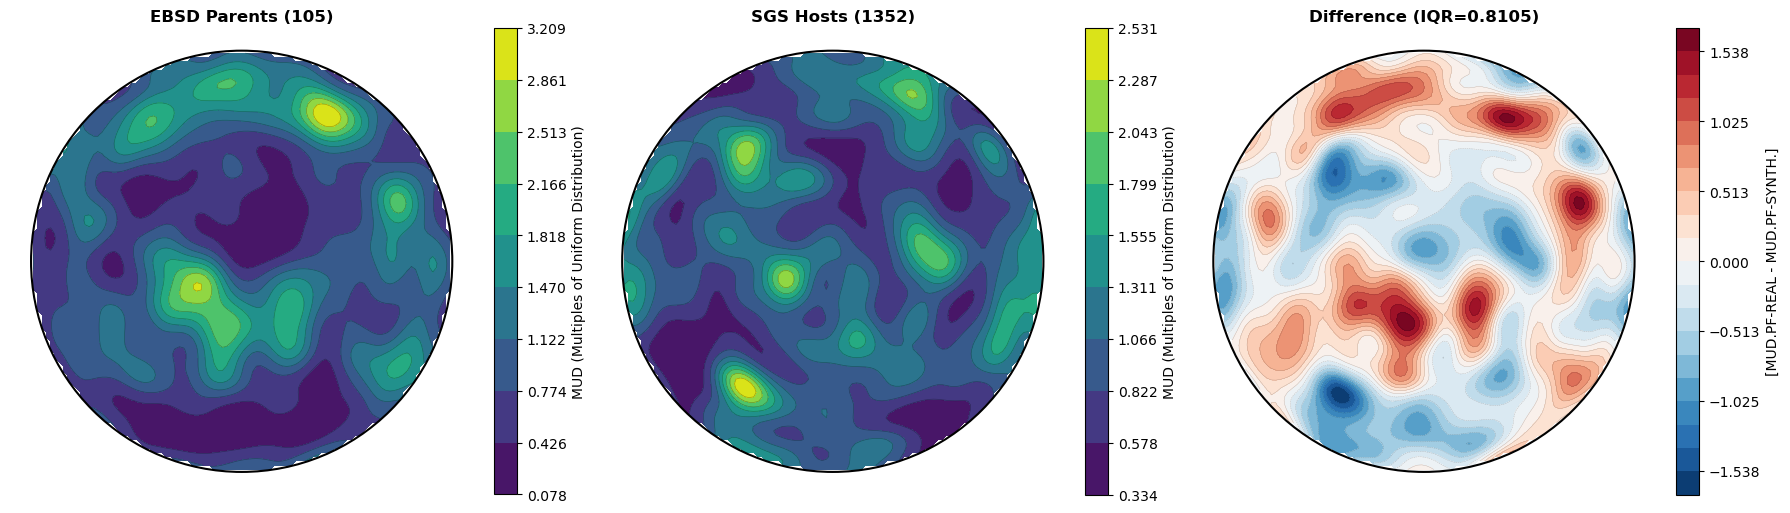

Parents-vs-hosts delta-MUD IQR: 0.811


In [54]:
fig, axes, iqr_full = steps_distribution_viewer.plot_texture_residual(
    ebsd_pf_stages['full'], sgs_pf_stages['full'],
    pole_family=POLE_FIGURE_FAMILY, half_width_deg=POLE_FIGURE_HALF_WIDTH_DEG,
    title_ebsd='EBSD Full', title_sgs='SGS Full')
report.add_image(fig, title='Texture Residual -- Full Structure', section='Distribution Viewer')
plt.show()
print(f'Full-structure delta-MUD IQR: {iqr_full:.3f}')

fig, axes, iqr_parents = steps_distribution_viewer.plot_texture_residual(
    ebsd_pf_stages['parents'], sgs_pf_stages['host'],
    pole_family=POLE_FIGURE_FAMILY, half_width_deg=POLE_FIGURE_HALF_WIDTH_DEG,
    title_ebsd='EBSD Parents', title_sgs='SGS Hosts')
report.add_image(fig, title='Texture Residual -- Parents vs Hosts', section='Distribution Viewer')
plt.show()
print(f'Parents-vs-hosts delta-MUD IQR: {iqr_parents:.3f}')

## Results Scorecard

The pass/fail and percentage results obtained thus far are distributed
across Parts J and M and the volume-fraction summary above. This section
consolidates them into a single assessment of overall pipeline
outcome.

In [55]:
pre_axes = pre_validator.axis_acceptance
post_axes = post_validator.axis_acceptance
twin_vf_ok = 90.0 <= pct_of_target <= 110.0
overall_verdict = ('PASS' if pre_validator.overall_accepted
                    and post_validator.overall_accepted and twin_vf_ok
                    else 'REVIEW NEEDED')

n_morph_accepted = sum(1 for s in role_prop_summary.values() if s['accepted'])
n_morph_total = len(role_prop_summary)

scorecard_rows = [
    {'stage': 'Pre-Twin Validation',
     'result': 'PASS' if pre_validator.overall_accepted else 'FAIL',
     'detail': f"{sum(a['accepted'] for a in pre_axes.values())}/{len(pre_axes)} axes accepted"},
    {'stage': 'Post-Twin Validation',
     'result': 'PASS' if post_validator.overall_accepted else 'FAIL',
     'detail': f"{sum(a['accepted'] for a in post_axes.values())}/{len(post_axes)} axes accepted"},
    {'stage': 'Twin Volume Fraction',
     'result': 'PASS' if twin_vf_ok else 'REVIEW',
     'detail': f'{pct_of_target:.1f}% of target ({achieved_total_vf:.4f} vs {target_total_vf:.4f})'},
    {'stage': 'Neighbour Misorientation (MDF) Repr.',
     'result': 'INFO',
     'detail': (f'score={mdf_repr_score:.3f} (0-1, higher=more alike)'
                if mdf_repr_score is not None else 'N/A')},
    {'stage': 'Twin Thickness (EBSD target vs. achieved 3D)',
     'result': 'PASS' if twin_thick_accepted else 'REVIEW',
     'detail': (f'ratio={twin_thick_repr_ratio:.2f} ({(twin_thick_repr_ratio - 1) * 100:+.1f}% vs EBSD), '
                f'score={twin_thick_repr_score:.3f}'
                if twin_thick_repr_ratio is not None else 'N/A')},
    {'stage': 'Texture -- Component VF Match',
     'result': 'INFO',
     'detail': (f"{texture_vf_comparison['total_abs_deviation_pct']:.1f} pp total deviation across "
                f"{len(texture_vf_comparison['matched'])} matched components")},
    {'stage': 'Texture -- Pole Figure Delta-MUD IQR',
     'result': 'INFO',
     'detail': f"IQR={pf_delta_mud['iqr']:.3f} (lower=more alike)"},
]
for prop, s in role_prop_summary.items():
    scorecard_rows.append({
        'stage': f'Morphology -- {prop}',
        'result': 'PASS' if s['accepted'] else 'REVIEW',
        'detail': (f"ratio={s['ratio']:.2f} ({(s['ratio'] - 1) * 100:+.1f}% vs EBSD), score={s['score']:.3f}"
                   if s['ratio'] is not None else 'N/A'),
    })
scorecard_rows.append({
    'stage': 'Morphology -- Overall',
    'result': 'PASS' if n_morph_accepted == n_morph_total else 'REVIEW',
    'detail': f'{n_morph_accepted}/{n_morph_total} properties within +/-{REPR_MATCH_TOLERANCE_PCT:.0f}% of EBSD',
})

print(f'Overall verdict: {overall_verdict}')
print()
for row in scorecard_rows:
    print(f"  [{row['result']:>6}]  {row['stage']:<44} {row['detail']}")

report.add_table(scorecard_rows, title='Results Scorecard', section='Summary')

Overall verdict: PASS

  [  PASS]  Pre-Twin Validation                          3/3 axes accepted
  [  PASS]  Post-Twin Validation                         3/3 axes accepted
  [  PASS]  Twin Volume Fraction                         96.2% of target (0.3431 vs 0.3568)
  [  INFO]  Neighbour Misorientation (MDF) Repr.         score=0.859 (0-1, higher=more alike)
  [REVIEW]  Twin Thickness (EBSD target vs. achieved 3D) ratio=0.56 (-44.3% vs EBSD), score=0.519
  [  INFO]  Texture -- Component VF Match                0.3 pp total deviation across 1 matched components
  [  INFO]  Texture -- Pole Figure Delta-MUD IQR         IQR=0.956 (lower=more alike)
  [REVIEW]  Morphology -- area                           ratio=1.70 (+70.0% vs EBSD), score=0.594
  [  PASS]  Morphology -- aspect_ratio                   ratio=0.91 (-8.5% vs EBSD), score=0.744
  [  PASS]  Morphology -- perimeter                      ratio=0.84 (-15.6% vs EBSD), score=0.601
  [  PASS]  Morphology -- solidity                      

TableEntry(id=36, timestamp='2026-09-17T00:52:36', title='Results Scorecard', columns=['stage', 'result', 'detail'], rows=[['Pre-Twin Validation', 'PASS', '3/3 axes accepted'], ['Post-Twin Validation', 'PASS', '3/3 axes accepted'], ['Twin Volume Fraction', 'PASS', '96.2% of target (0.3431 vs 0.3568)'], ['Neighbour Misorientation (MDF) Repr.', 'INFO', 'score=0.859 (0-1, higher=more alike)'], ['Twin Thickness (EBSD target vs. achieved 3D)', 'REVIEW', 'ratio=0.56 (-44.3% vs EBSD), score=0.519'], ['Texture -- Component VF Match', 'INFO', '0.3 pp total deviation across 1 matched components'], ['Texture -- Pole Figure Delta-MUD IQR', 'INFO', 'IQR=0.956 (lower=more alike)'], ['Morphology -- area', 'REVIEW', 'ratio=1.70 (+70.0% vs EBSD), score=0.594'], ['Morphology -- aspect_ratio', 'PASS', 'ratio=0.91 (-8.5% vs EBSD), score=0.744'], ['Morphology -- perimeter', 'PASS', 'ratio=0.84 (-15.6% vs EBSD), score=0.601'], ['Morphology -- solidity', 'PASS', 'ratio=1.12 (+11.7% vs EBSD), score=0.264'], [

## Temporal-Slice Sweep

Part G's ranking selects a single "best" temporal slice from cheap, 2D
cross-sectional comparisons alone; it cannot know a slice's actual
achieved total twin volume fraction, since that quantity exists only
once the full downstream pipeline (host allocation, orientation
assignment, twin generation, cleaning) has run for that slice. This
section re-runs that downstream chain for every requested slice and
reports which reach `SWEEP_VF_THRESHOLD_PCT` of the EBSD-partitioned
target.

`SWEEP_TSLICE_KEYS`: `None` (or an empty list) sweeps every saved slice
except the un-annealed seed at index 0; an explicit list restricts the
sweep to those keys, with any key not actually present in this run
dropped and reported, rather than raising an error. Host allocation and
twin generation reuse the settings already configured in Parts I and L;
orientation assignment uses a single, fast `conflict_free` run per slice
(rather than repeating Part K's mapping optimization for every slice
swept, which would multiply the already substantial cost of this section
by a further factor of ten) -- the volume fraction achieved depends
primarily on host geometry and the probability parameters governing twin
introduction, not on which orientation-assignment mode was used.

`SWEEP_N_WORKERS`: `1` (default) sweeps every slice sequentially, in
this process. A value greater than 1 instead distributes the requested
slices across that many worker processes, since each slice's downstream
chain is independent of every other slice's -- process-based rather than
thread-based, because the per-slice work is ordinary CPU/NumPy-bound
Python that the interpreter's global lock would otherwise prevent from
actually overlapping across threads. The inputs shared by every slice
(`pxt`, `rg`, `parent_info`, the four kwargs dicts) are transferred to
each worker process once, at start-up, rather than once per slice.
Effective only when more than one slice is swept; on a machine with
fewer available cores than `SWEEP_N_WORKERS`, or fewer slices than
`SWEEP_N_WORKERS`, the smaller of the two applies.

Data export protocol: every slice reaching the threshold is written
under ONE shared master folder for this sweep,
`<output_dir>/TwinnedFCC/Grain Structures/<base_filename><N>/`
(auto-numbered, picked once at the start of the sweep, not once per
slice), with each passing slice in its own `tslice_<key>/` subfolder
inside it. A single, non-swept export -- as `export_raw()` is used
elsewhere in this notebook (Part P) -- writes its files directly under
its own master folder instead, with no `tslice_<key>` level; the two
cases share the same underlying convention and never collide with each
other or across repeated runs. Abaqus mesh export is not performed here;
re-run Parts I-P for one specific `tslice_key` afterward if a mesh is
required for a particular passing slice.

In [56]:
SWEEP_TSLICE_KEYS = None            # None/[] = every saved slice except index 0; or an explicit list of keys
SWEEP_VF_THRESHOLD_PCT = 90.0       # minimum achieved-VF-as-percent-of-target to count as passing
SWEEP_N_WORKERS = 3                 # 1 = sequential; >1 = that many worker processes (see markdown above)

sweep_rows = steps_temporal_slice_sweep.sweep_temporal_slices(
    pxt, rg, parent_info, vf_targets, twin_thickness,
    tslice_keys=SWEEP_TSLICE_KEYS, vf_threshold_pct=SWEEP_VF_THRESHOLD_PCT,
    n_workers=SWEEP_N_WORKERS,
    host_alloc_kwargs=dict(
        target_fraction=HOST_TARGET_FRACTION, min_voxels=HOST_MIN_VOXELS,
        scale_factor=HOST_2D_TO_3D_SCALE_FACTOR, ranking_weight=HOST_RANKING_VOLUME_WEIGHT,
        mis_fraction=HOST_MIS_FRACTION, mis_runs=HOST_MIS_RUNS, seed=HOST_SEED,
        pool_b_band_shape=HOST_POOL_B_BAND_SHAPE, pool_b_n_std=HOST_POOL_B_N_STD),
    orientation_kwargs=dict(csl_label=CSL_LABEL, ori_mode='conflict_free', rng_seed=42),
    twin_gen_kwargs=dict(
        csl_label=CSL_LABEL, n_lamellae_per_host=TWIN_N_LAMELLAE_PER_HOST,
        nucleation_site='gb_centroid', meshing_route='conformal',
        tvf_tolerance=TWIN_TVF_TOLERANCE, thick_scale_factor=TWIN_THICK_SCALE_FACTOR,
        max_vf_per_host=TWIN_MAX_VF_PER_HOST, prob_sec_outward=TWIN_PROB_SEC_OUTWARD,
        prob_sec_inward=TWIN_PROB_SEC_INWARD, rng_seed=TWIN_RNG_SEED),
    clean_kwargs=dict(n_passes=5))

n_passing = sum(1 for r in sweep_rows if r.get('passes'))
print()
print(f'{n_passing}/{len(sweep_rows)} swept slice(s) reached {SWEEP_VF_THRESHOLD_PCT:.0f}% of target.')

sweep_table_rows = [{k: v for k, v in r.items() if k != 'export'} for r in sweep_rows]
report.add_table(sweep_table_rows, title='Temporal-Slice Sweep', section='Summary')

Sweeping 19 slices across 3 worker processes ...
  tslice_key=10: achieved_total_vf=0.3476  pct_of_target=97.4%  hosting_fraction=0.9206  n_conflicts=0  n_grains=1872  PASS
  tslice_key=15: achieved_total_vf=0.3467  pct_of_target=97.2%  hosting_fraction=0.9294  n_conflicts=0  n_grains=1506  PASS
  tslice_key=5: achieved_total_vf=0.3431  pct_of_target=96.1%  hosting_fraction=0.9168  n_conflicts=0  n_grains=2781  PASS
  tslice_key=20: achieved_total_vf=0.3476  pct_of_target=97.4%  hosting_fraction=0.9319  n_conflicts=0  n_grains=1370  PASS
  tslice_key=35: achieved_total_vf=0.3542  pct_of_target=99.2%  hosting_fraction=0.9499  n_conflicts=0  n_grains=921  PASS
  tslice_key=25: achieved_total_vf=0.3481  pct_of_target=97.5%  hosting_fraction=0.9367  n_conflicts=0  n_grains=1245  PASS
  tslice_key=30: achieved_total_vf=0.3591  pct_of_target=100.6%  hosting_fraction=0.9381  n_conflicts=0  n_grains=986  PASS
  tslice_key=45: achieved_total_vf=0.3495  pct_of_target=97.9%  hosting_fraction=0.93

TableEntry(id=37, timestamp='2026-09-17T00:53:07', title='Temporal-Slice Sweep', columns=['tslice_key', 'achieved_total_vf', 'target_total_vf', 'pct_of_target', 'passes', 'achieved_hosting_fraction', 'n_host_grains', 'n_conflicts', 'n_grains_clean'], rows=[[5, 0.34309579271924073, np.float64(0.35684818481848185), np.float64(96.14615046837451), np.True_, 0.9167816299914814, 418, 0, 2781], [10, 0.347649094239772, np.float64(0.35684818481848185), np.float64(97.422127680602), np.True_, 0.9206489208524625, 272, 0, 1872], [15, 0.34669169474787226, np.float64(0.35684818481848185), np.float64(97.1538344588257), np.True_, 0.9293785949597063, 205, 0, 1506], [20, 0.3475586312956555, np.float64(0.35684818481848185), np.float64(97.39677713996171), np.True_, 0.9319115573949688, 162, 0, 1370], [25, 0.3480787932243255, np.float64(0.35684818481848185), np.float64(97.54254274864334), np.True_, 0.936683477697115, 137, 0, 1245], [30, 0.3591303495638932, np.float64(0.35684818481848185), np.float64(100.6395

## Finish: Report Generation

Renders the accumulated `add_table`/`add_image` entries into a single
`report.html` file.

In [57]:
report_path = steps_visualization_export.finish_report(report)
print('Report written to:', report_path)

Report written to: C:\Development\UPXO\upxo_library\data\TwinnedFCC\Reports\adv1\report.html
